Despite having rich customer-level data, banks often lack:
	• Accurate churn prediction models
	• Quantitative churn risk scores
	• Explainable insights into churn drivers
As a result, retention actions are:
	• Reactive rather than proactive
	• Broad rather than targeted
	• Inefficient and costly
Primary Objectives
	• Predict customer churn with high accuracy
	• Generate churn probability scores
	• Identify key churn drivers
Secondary Objectives
	• Reduce false positives in churn detection
	• Improve interpretability of ML models
	• Enable scenario-based churn risk analysis


### INSTALL REQUIRED LIBRARIES

In [2]:
!pip install mysql-connector-python
!pip install pandas
!pip install sqlalchemy
!pip install pymysql
!pip install cryptography
!pip install mysql-connector-python


In [3]:
# Import Required Libraries


import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler
)

# Train Test Split
from sklearn.model_selection import train_test_split

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)

# Visualization Style
sns.set_style('darkgrid')

In [6]:
import mysql.connector
import pandas as pd

conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="SKNayak#2002@",
    database="european_central_bank"
)

query = "SELECT * FROM european_bank"

df = pd.read_sql(query, conn)

df.head()

,Year,MyUnknownColumn,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### CONNECT MYSQL TO JUPYTER

### INITIAL INSPECTION

In [10]:
print (df.describe())
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.info())

          Year  MyUnknownColumn   CreditScore           Age        Tenure  \
count  10000.0     1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    2025.0     1.569094e+07    650.528800     38.921800      5.012800   
std        0.0     7.193619e+04     96.653299     10.487806      2.892174   
min     2025.0     1.556570e+07    350.000000     18.000000      0.000000   
25%     2025.0     1.562853e+07    584.000000     32.000000      3.000000   
50%     2025.0     1.569074e+07    652.000000     37.000000      5.000000   
75%     2025.0     1.575323e+07    718.000000     44.000000      7.000000   
max     2025.0     1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000       1.00000

In [12]:
print(df.isnull().sum())
print(df.duplicated().sum())

Year               0
MyUnknownColumn    0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0


* No missing values no duplicate values
* All data type seems right but one coumn name 'MyUnknownColumn'is missing and need to change into 'Customer_id'
* 

In [15]:
df['Exited'].unique()

array([1, 0])

In [17]:
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

* target variable is imbalance so need to treat class imbalance

In [20]:
df_copy = df.copy()

In [22]:
df_copy.head()

,Year,MyUnknownColumn,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [24]:
df_copy= df_copy.drop(columns=['MyUnknownColumn','Surname'])

In [26]:
df_copy.columns

Index(['Year', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='str')

In [28]:

# Import Required Libraries


import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)

# Visualization Style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [30]:
# Separate Numerical & Categorical Columns
num_cols= df_copy.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols= df_copy.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns")
print(num_cols)

print("\n Catagorical Columns")
print(cat_cols)

Numeric Columns
['Year', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

 Catagorical Columns
['Geography', 'Gender']


#### Univariate Analysis (Numerical Features)

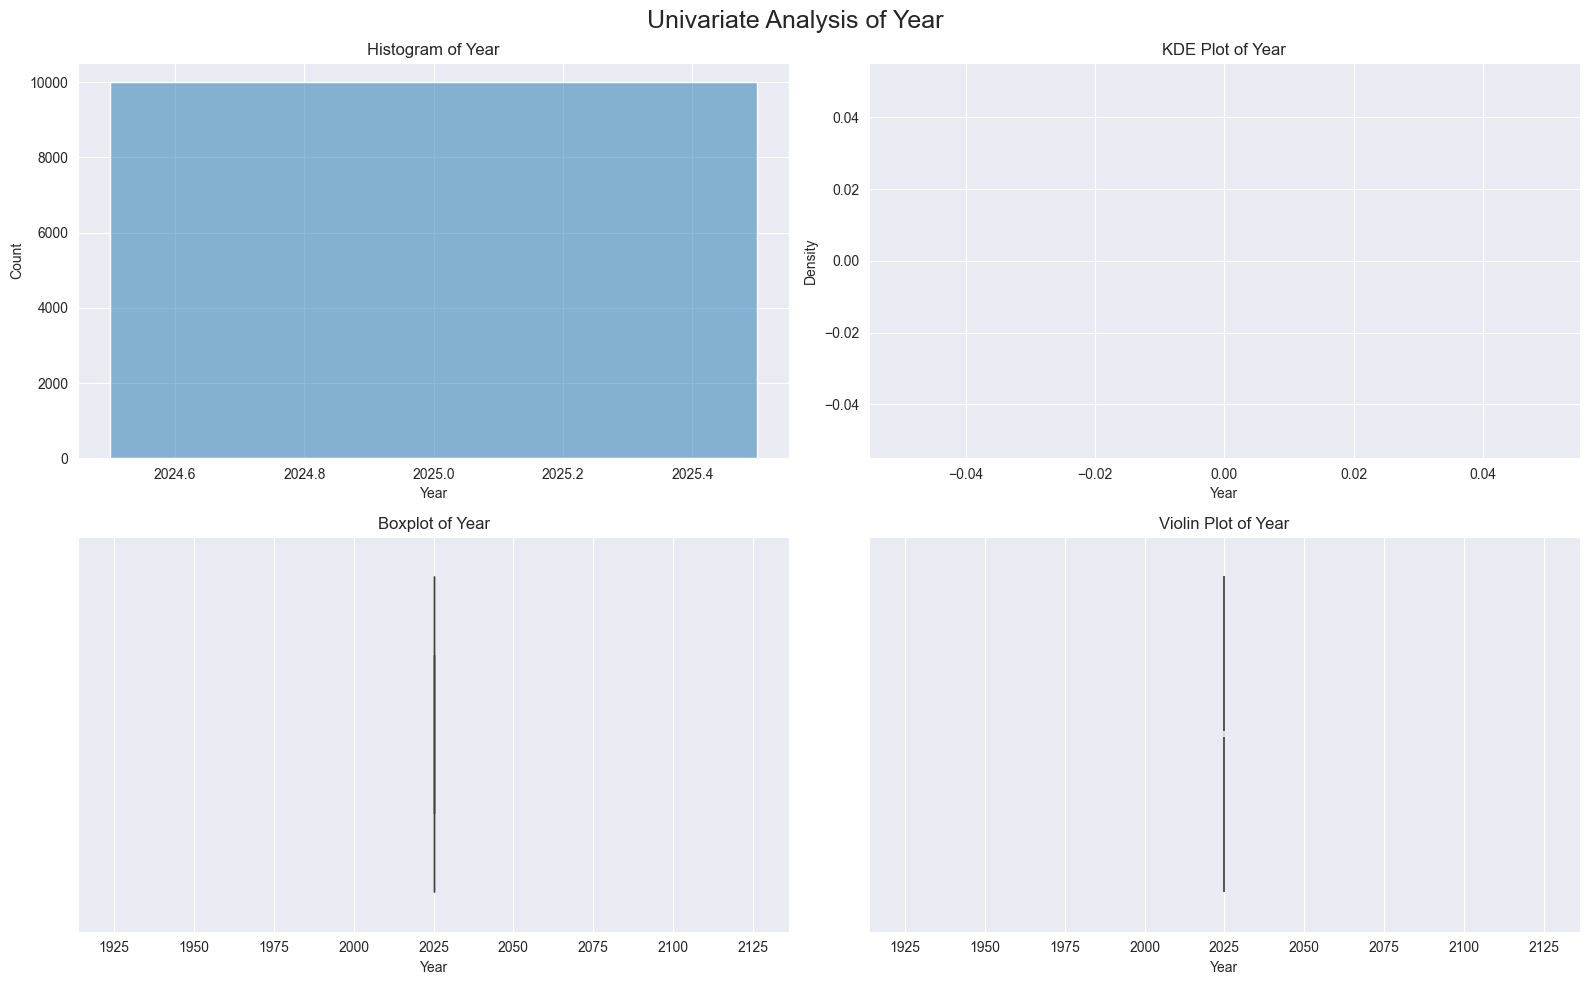

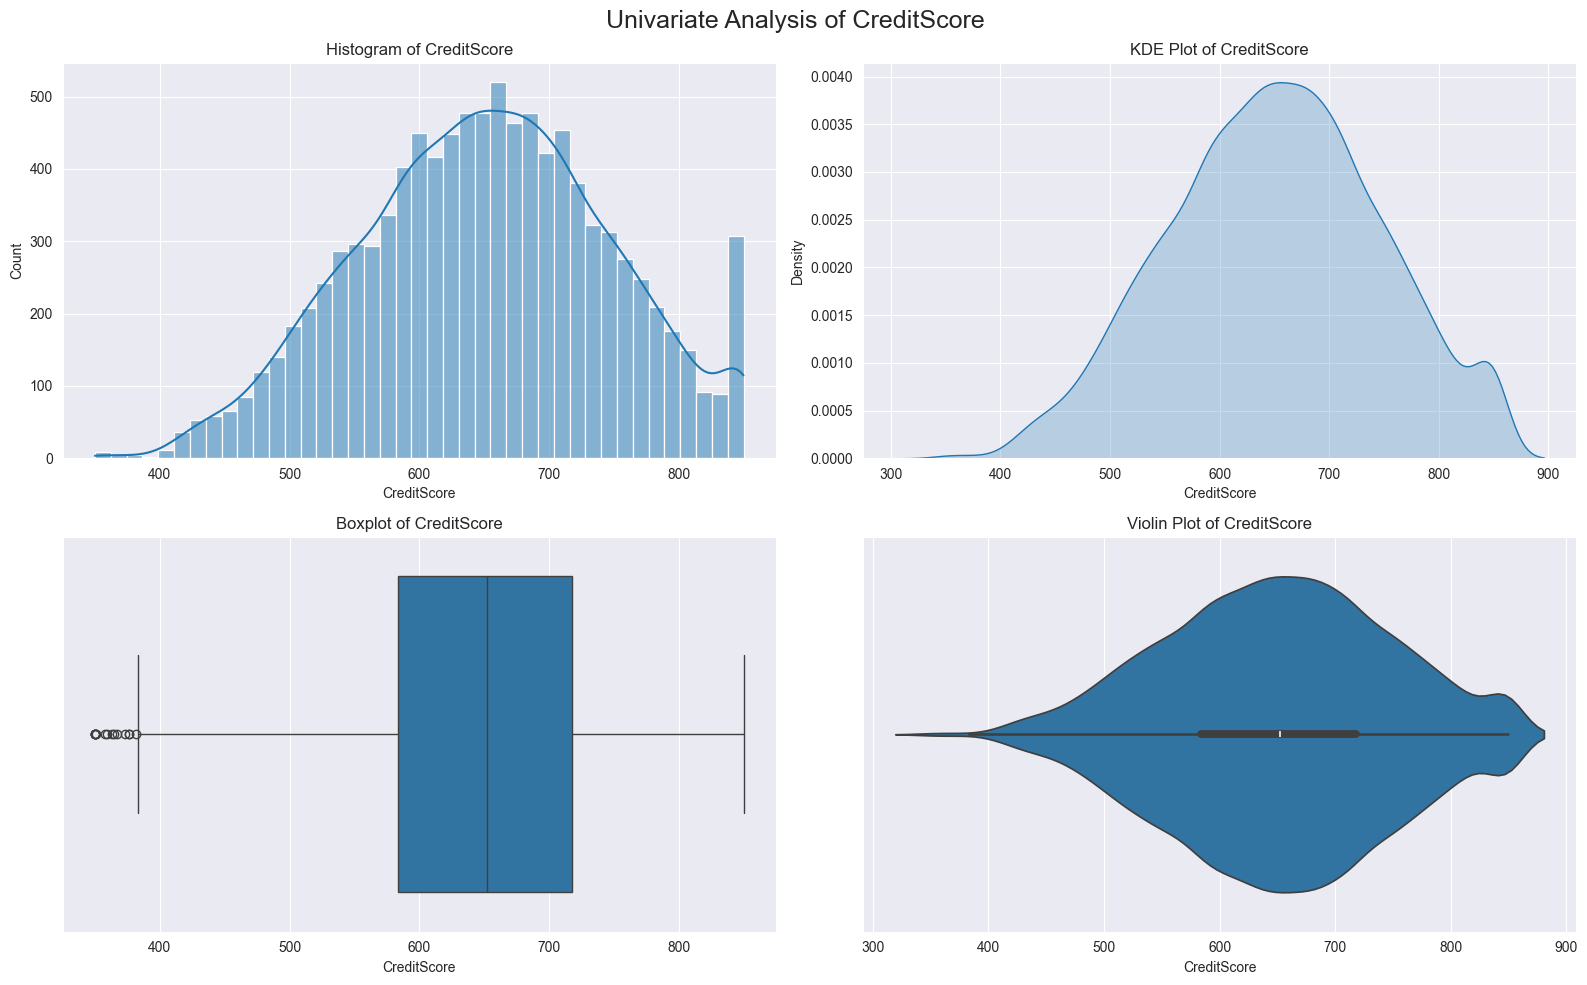

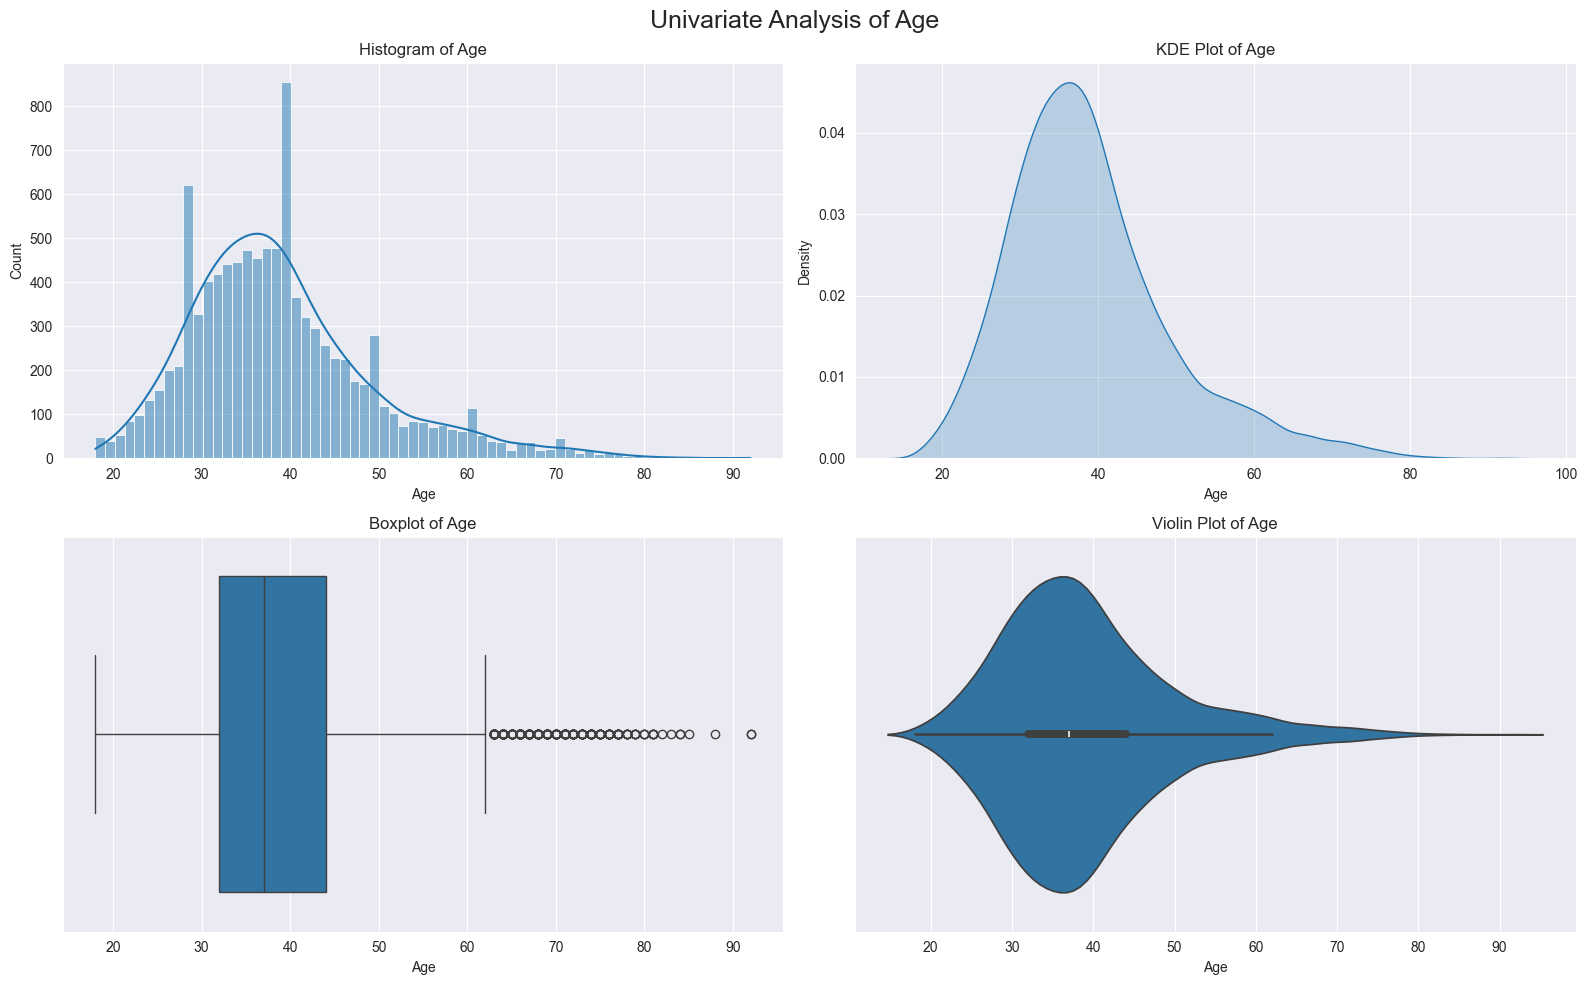

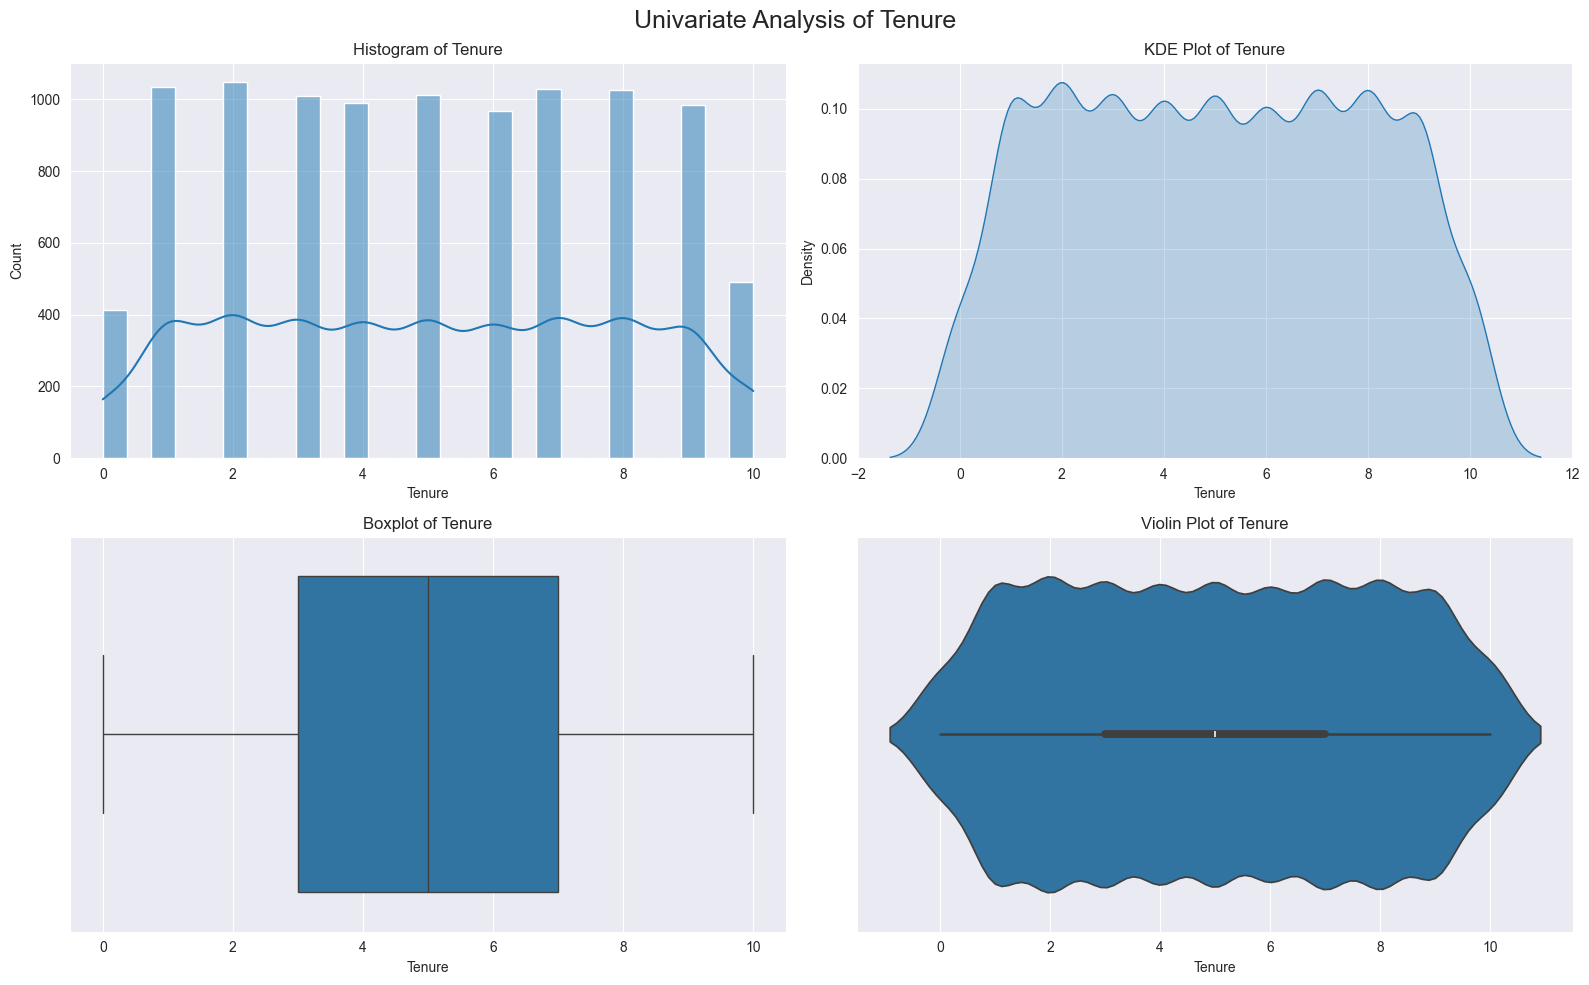

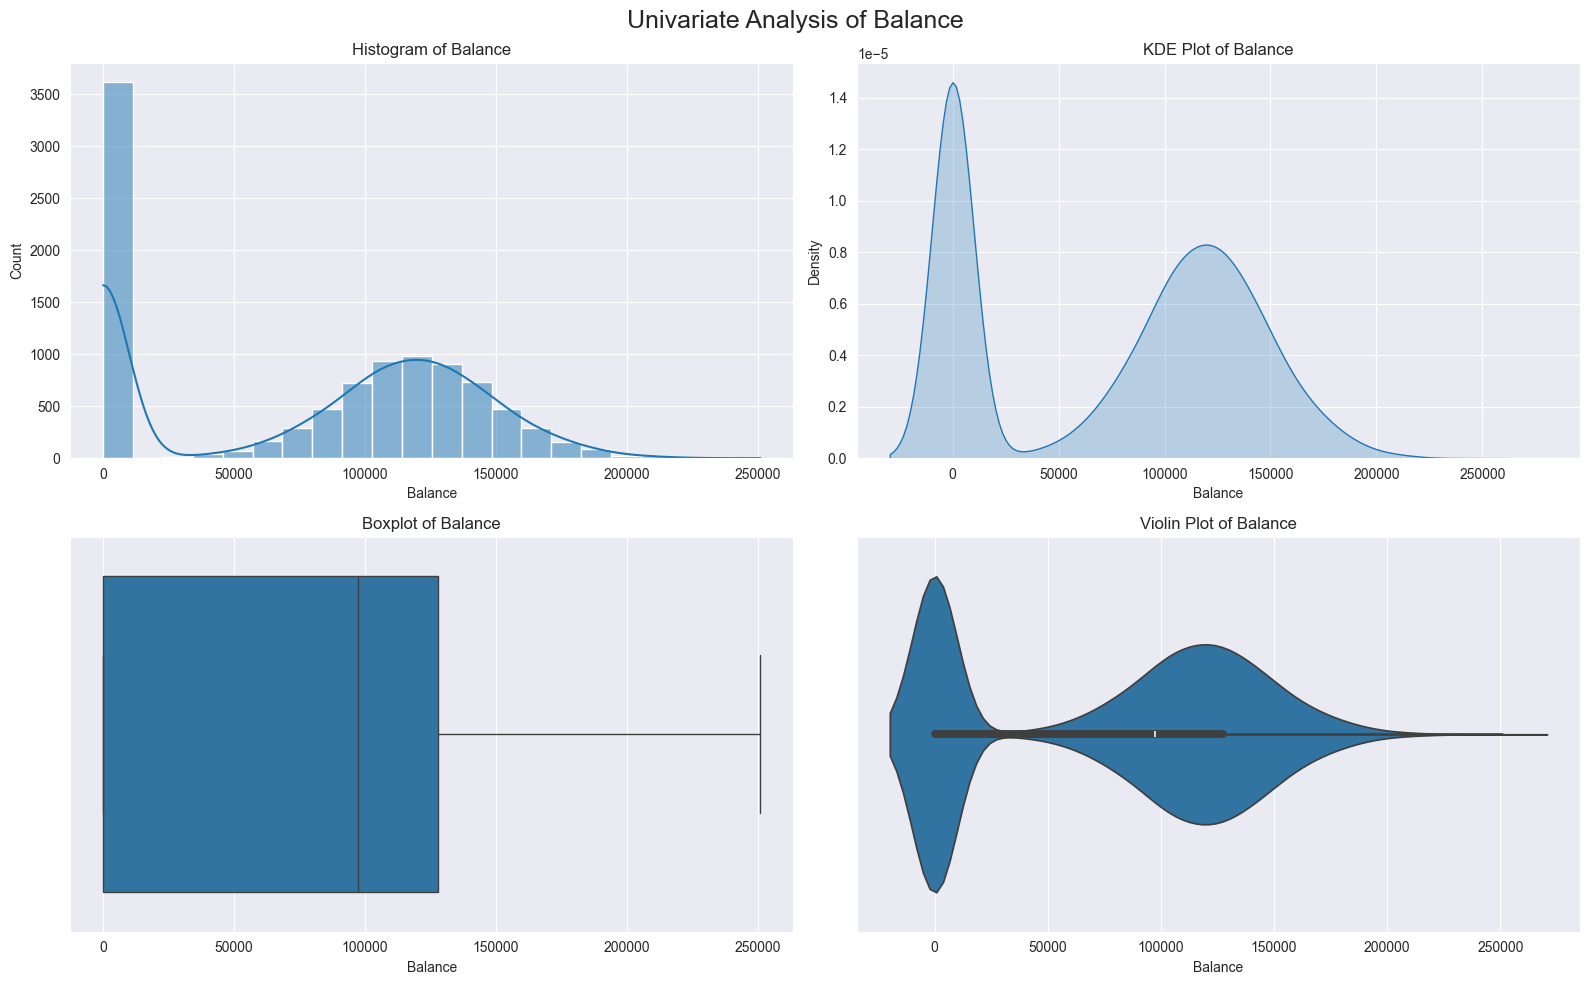

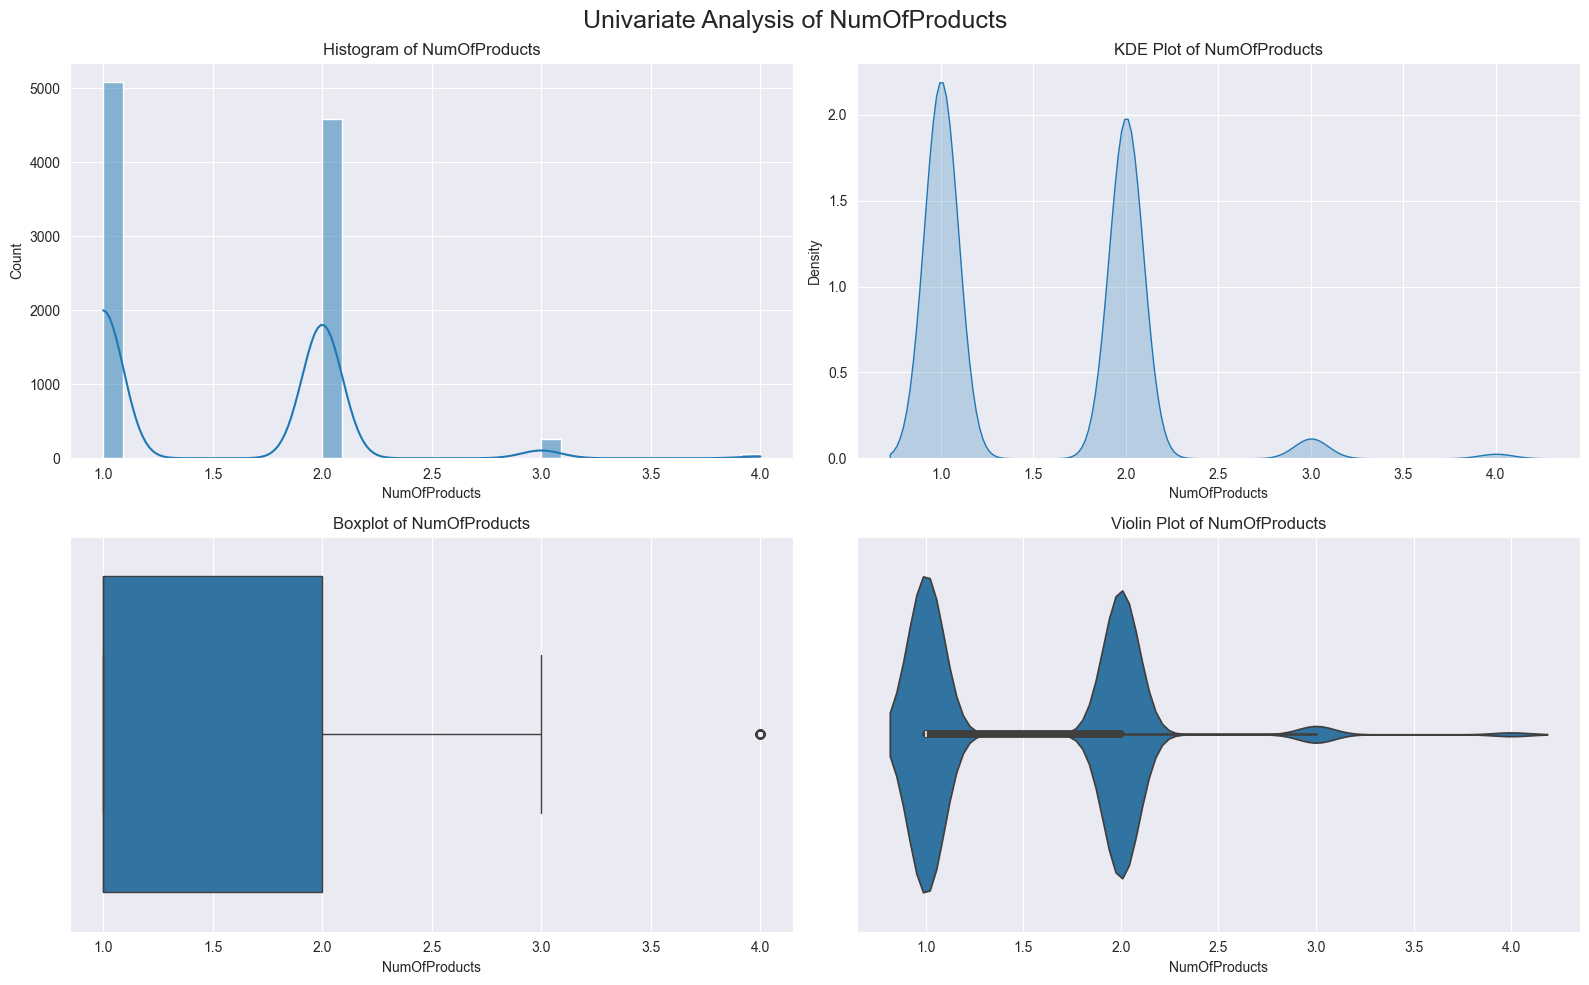

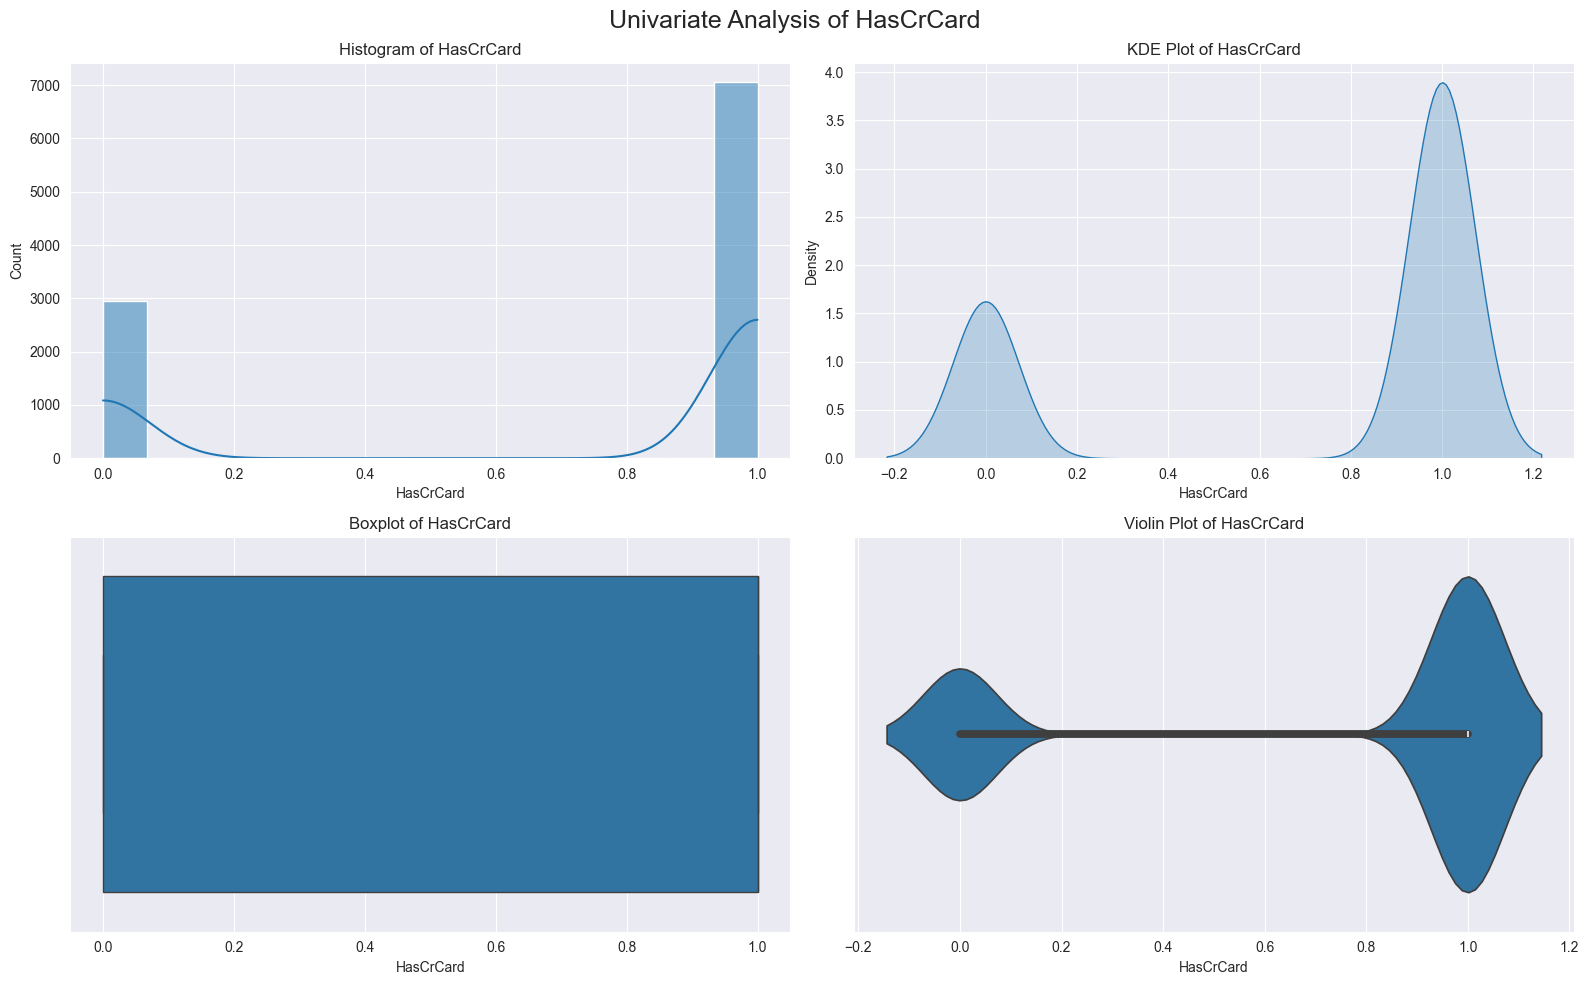

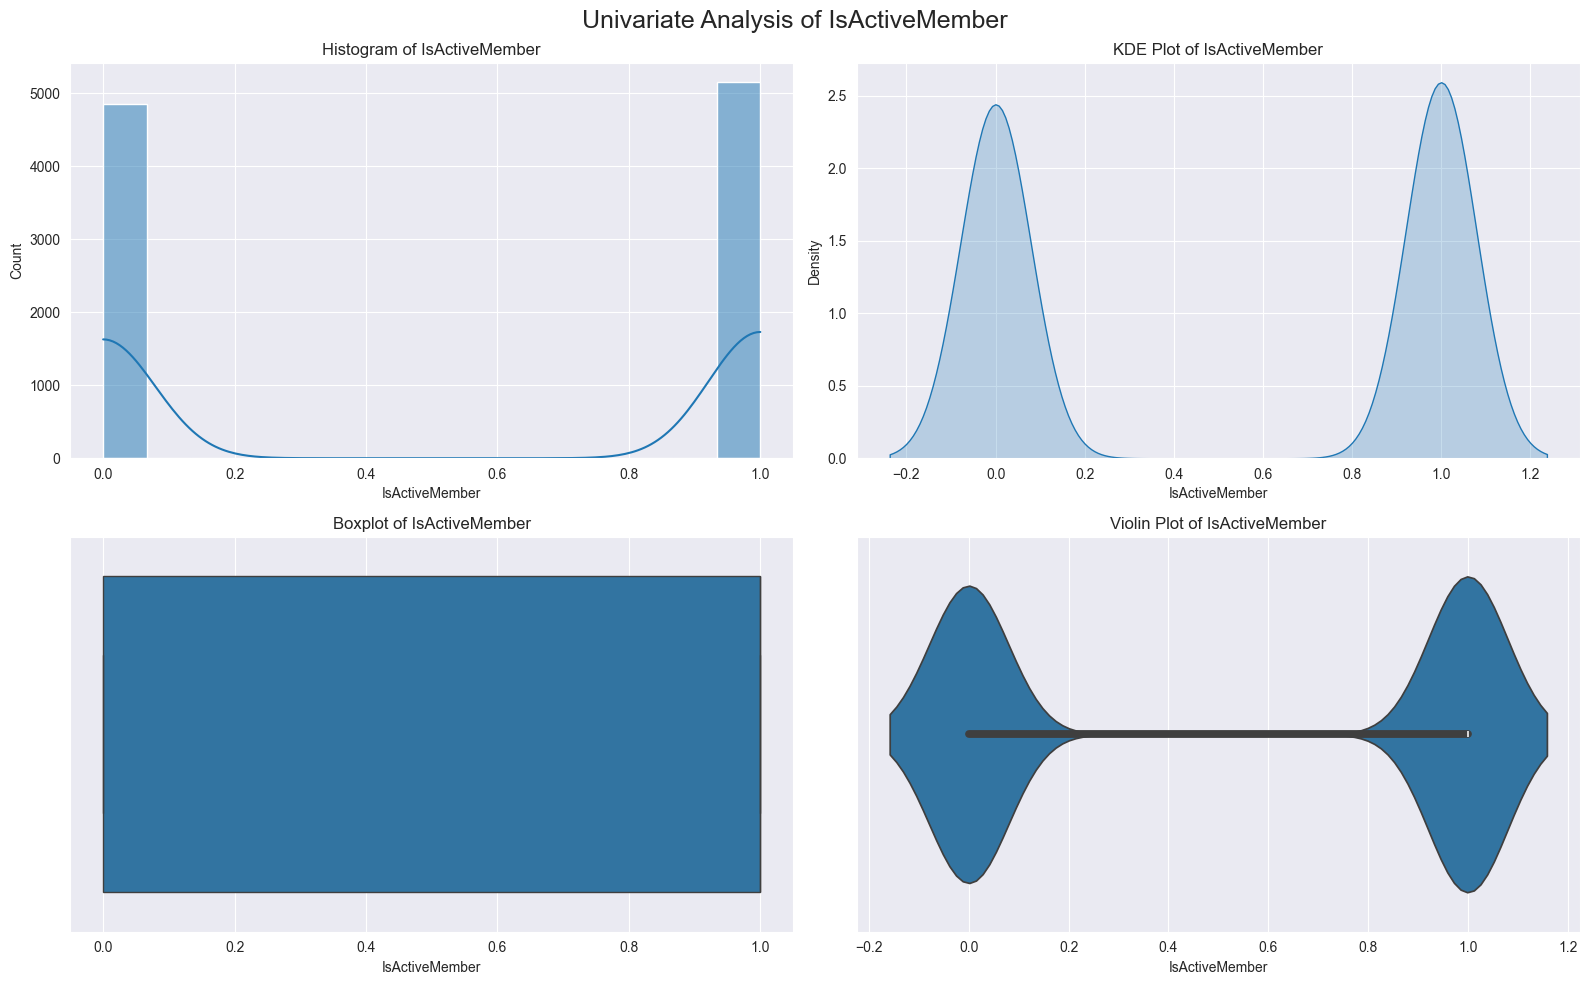

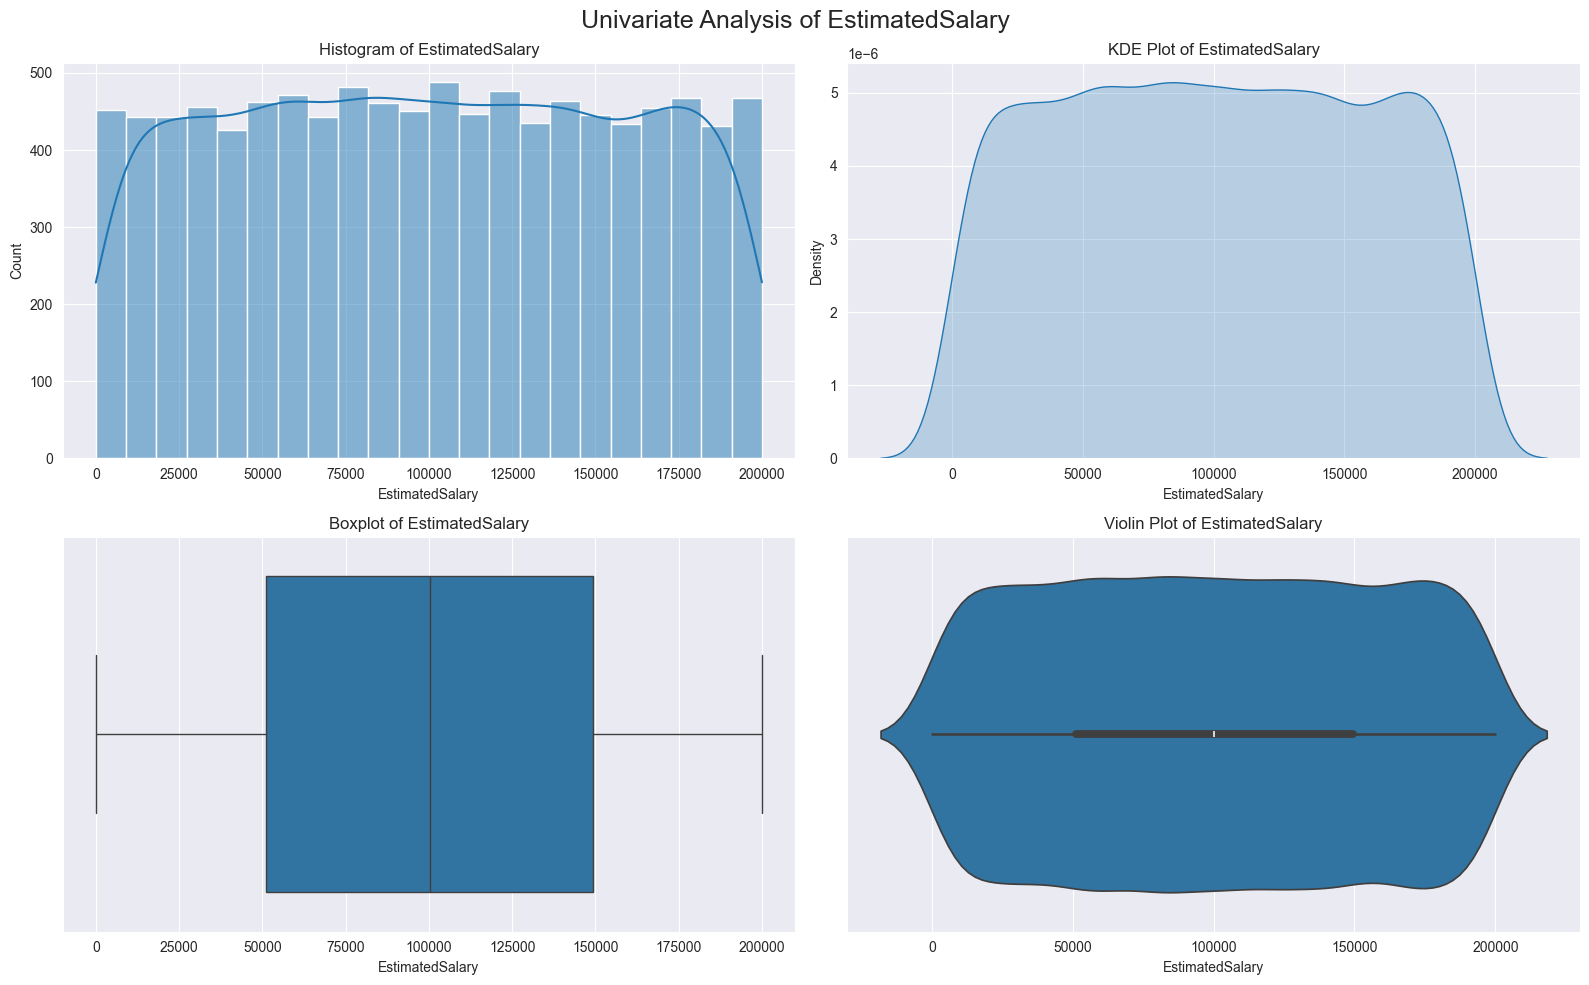

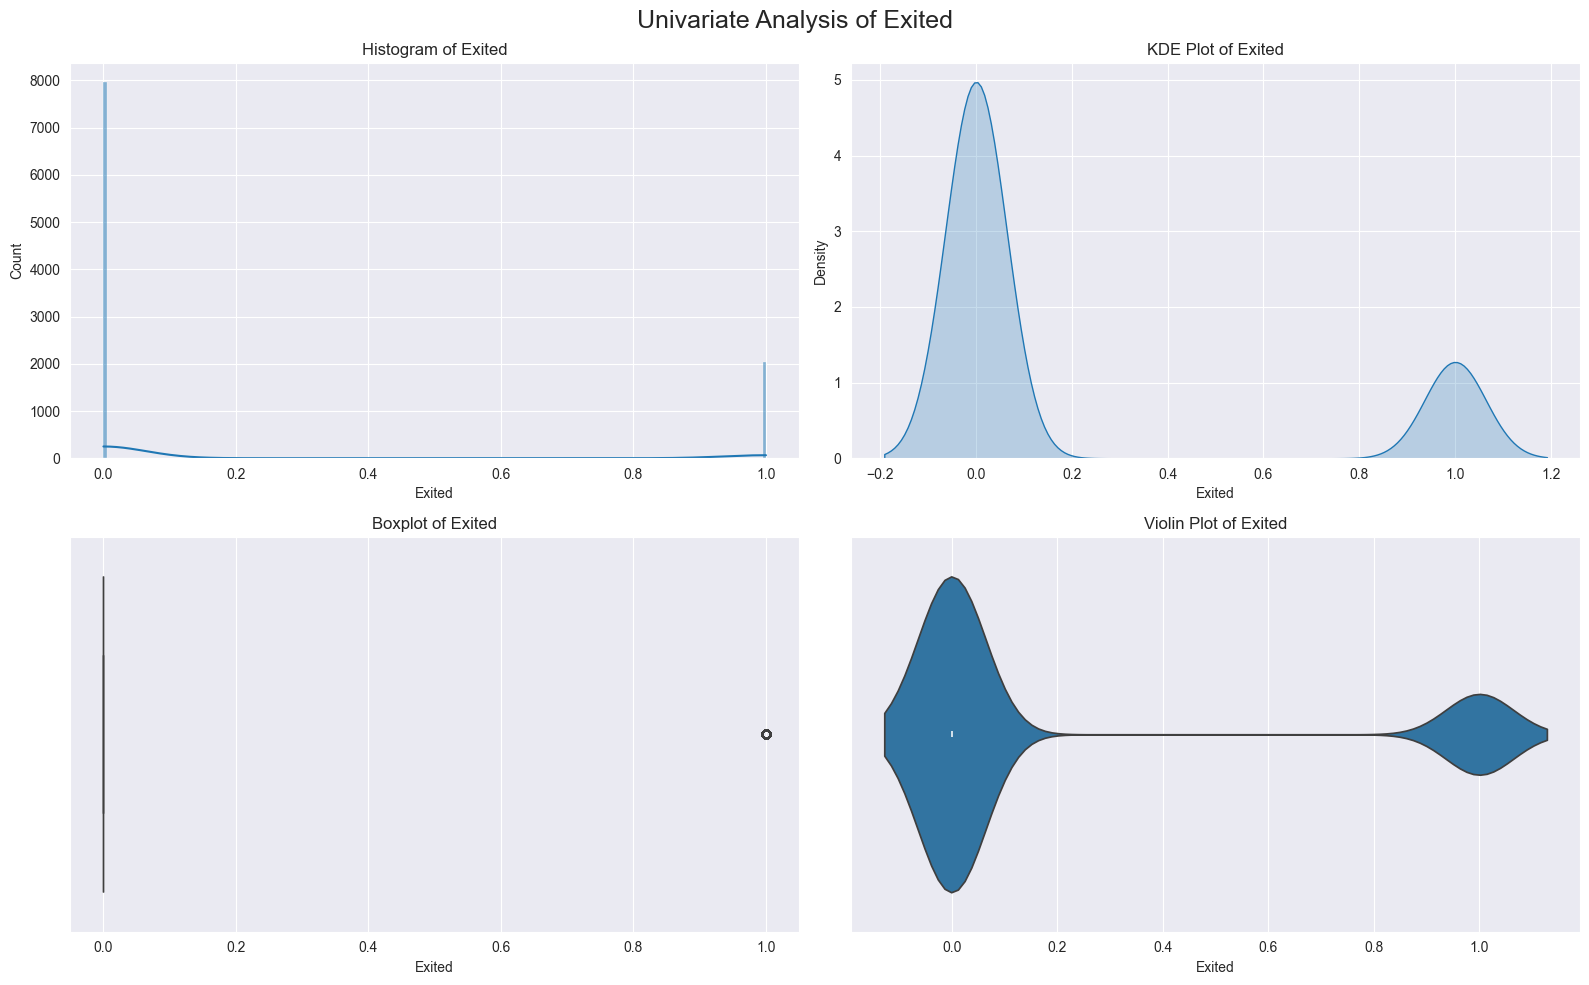

In [33]:

# Univariate Analysis - Numerical Features


for col in num_cols:
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Histogram
    sns.histplot(df_copy[col], kde=True, ax=axes[0,0])
    axes[0,0].set_title(f'Histogram of {col}')
    
    # KDE Plot
    sns.kdeplot(df_copy[col], fill=True, ax=axes[0,1])
    axes[0,1].set_title(f'KDE Plot of {col}')
    
    # Boxplot
    sns.boxplot(x=df_copy[col], ax=axes[1,0])
    axes[1,0].set_title(f'Boxplot of {col}')
    
    # Violin Plot
    sns.violinplot(x=df_copy[col], ax=axes[1,1])
    axes[1,1].set_title(f'Violin Plot of {col}')
    
    plt.suptitle(f'Univariate Analysis of {col}', fontsize=18)
    
    plt.tight_layout()
    plt.show()

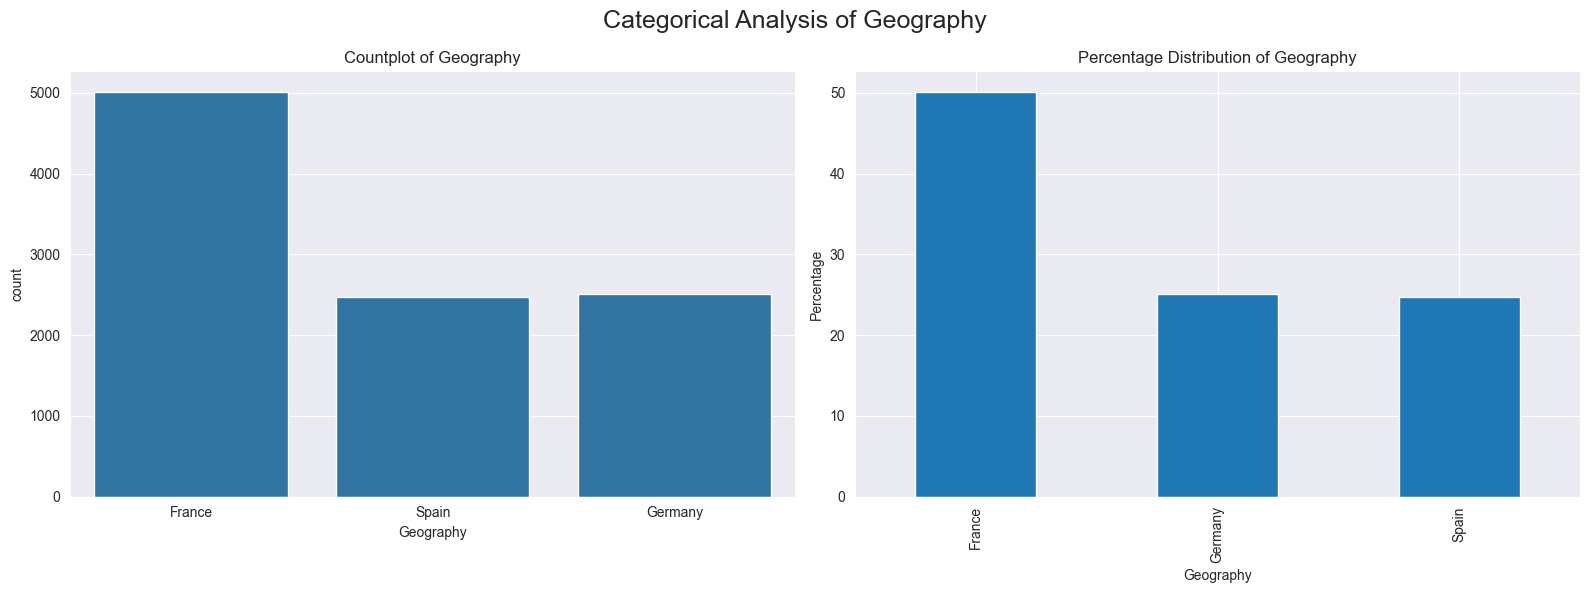

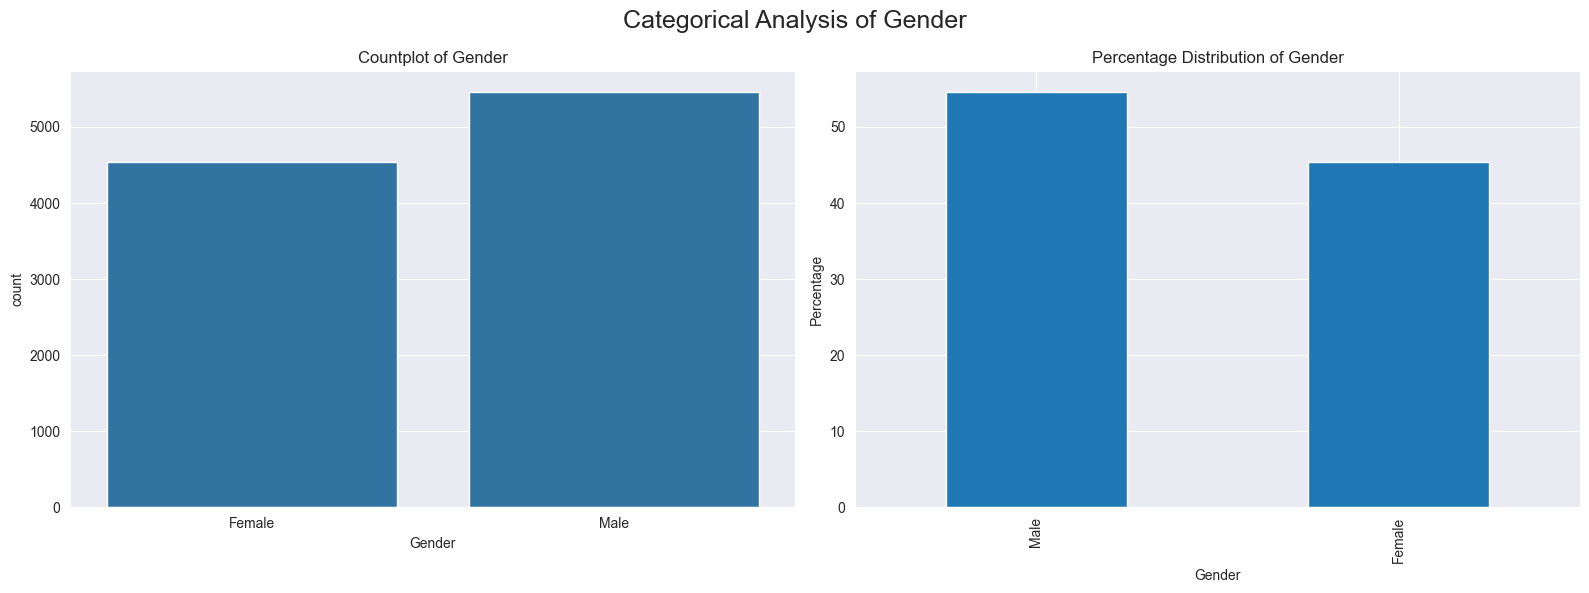

In [34]:

# Univariate Analysis - Categorical Features


for col in cat_cols:
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Countplot
    sns.countplot(x=df_copy[col], ax=axes[0])
    axes[0].set_title(f'Countplot of {col}')
    
    # Percentage Distribution
    percentage = df_copy[col].value_counts(normalize=True) * 100
    
    percentage.plot(
        kind='bar',
        ax=axes[1]
    )
    
    axes[1].set_title(f'Percentage Distribution of {col}')
    axes[1].set_ylabel('Percentage')
    
    plt.suptitle(f'Categorical Analysis of {col}', fontsize=18)
    
    plt.tight_layout()
    plt.show()

#### Target Variable Distribution

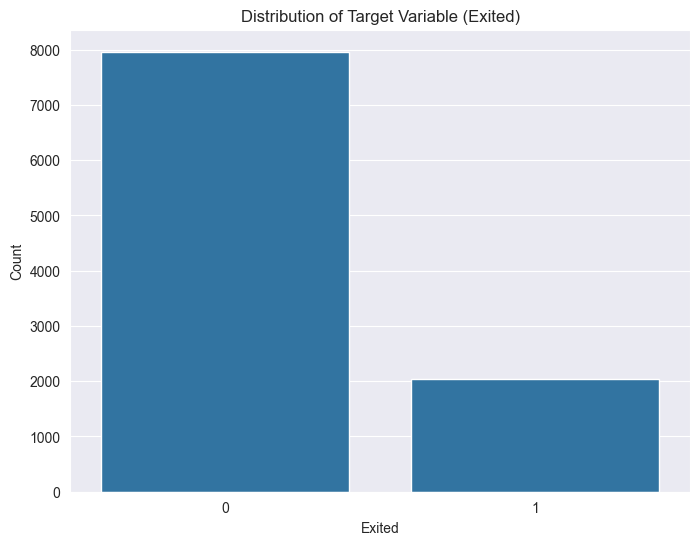

In [38]:

# Target Variable Distribution


plt.figure(figsize=(8,6))

sns.countplot(x=df_copy['Exited'])

plt.title('Distribution of Target Variable (Exited)')
plt.xlabel('Exited')
plt.ylabel('Count')

plt.show()

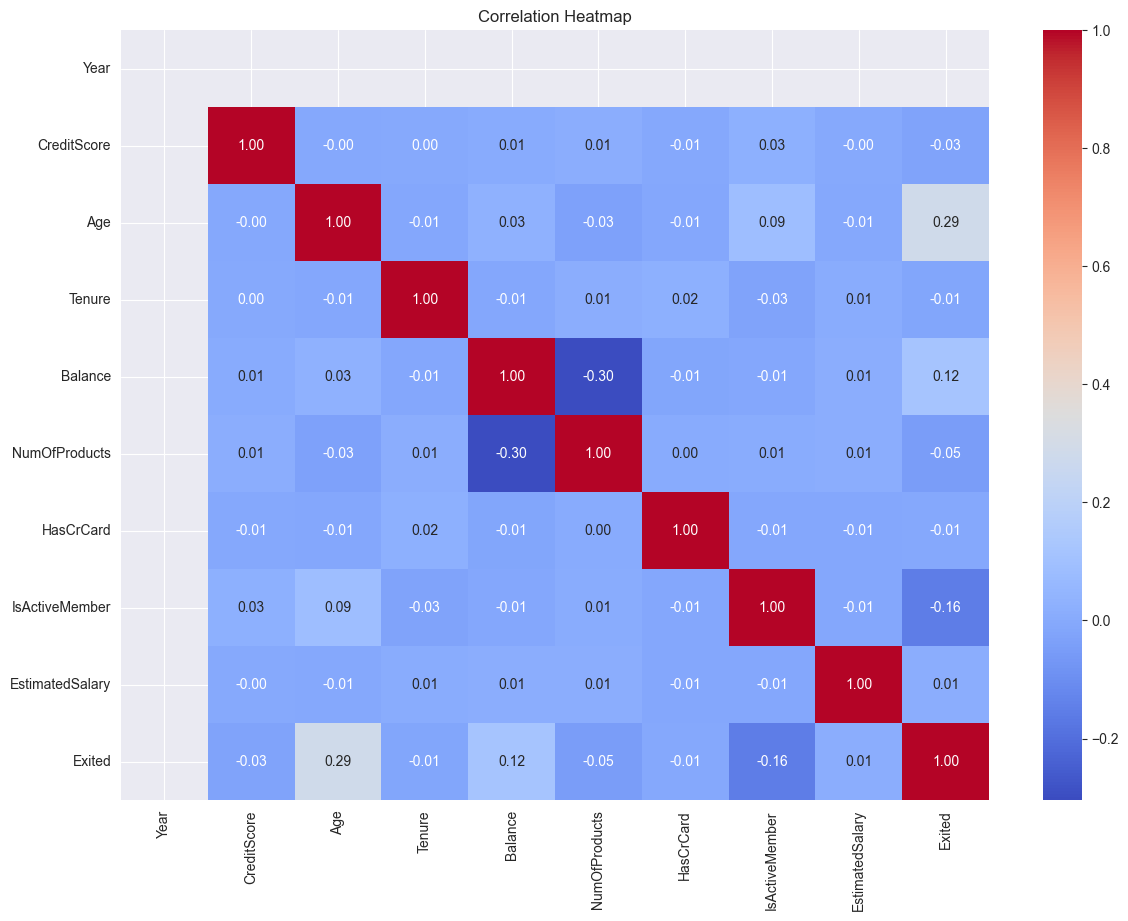

In [40]:

# Correlation Heatmap


plt.figure(figsize=(14,10))

sns.heatmap(
    df_copy.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

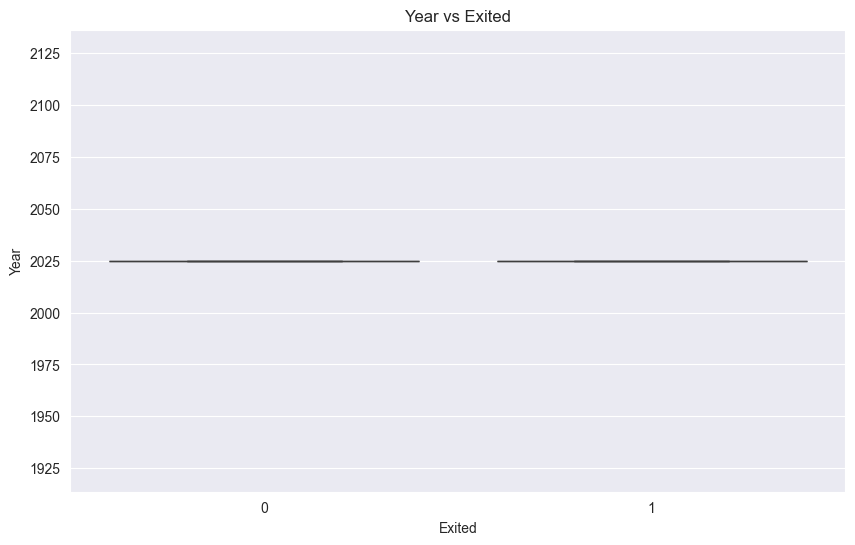

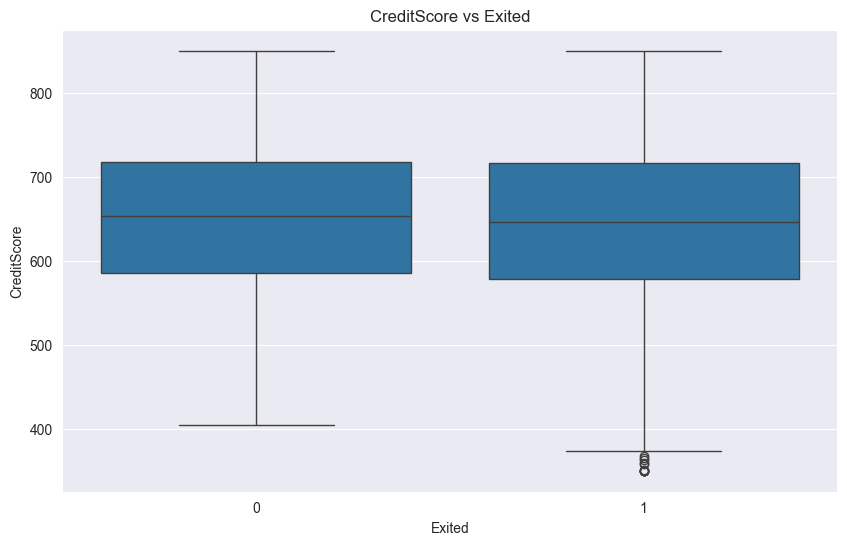

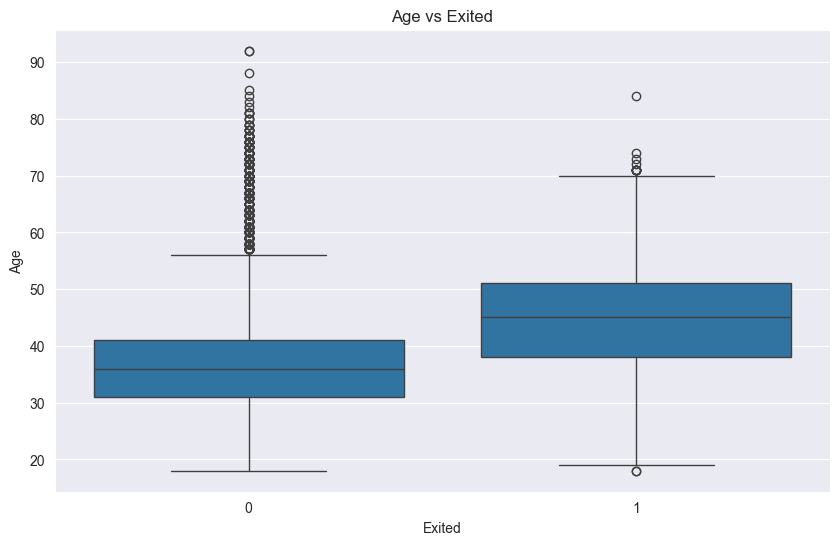

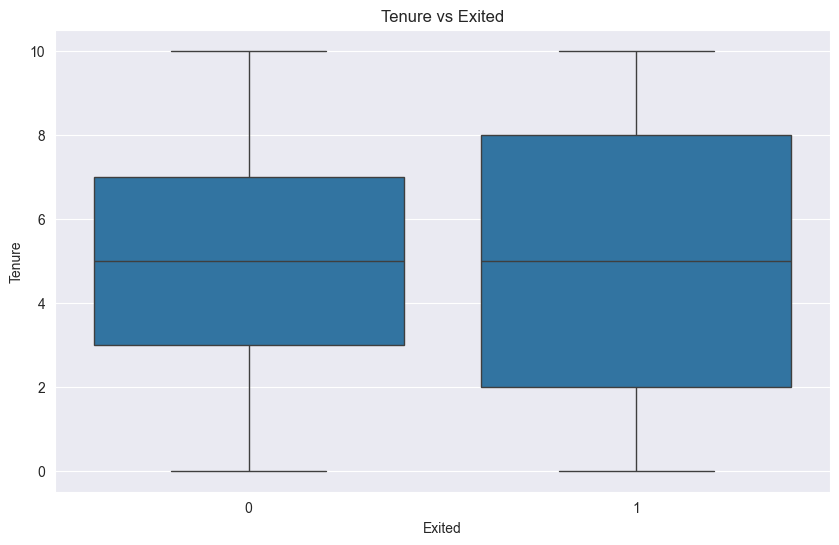

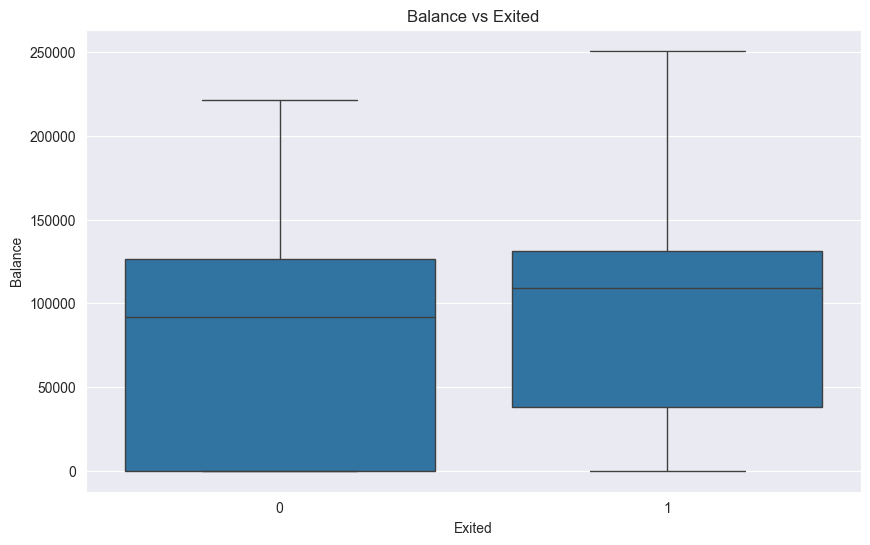

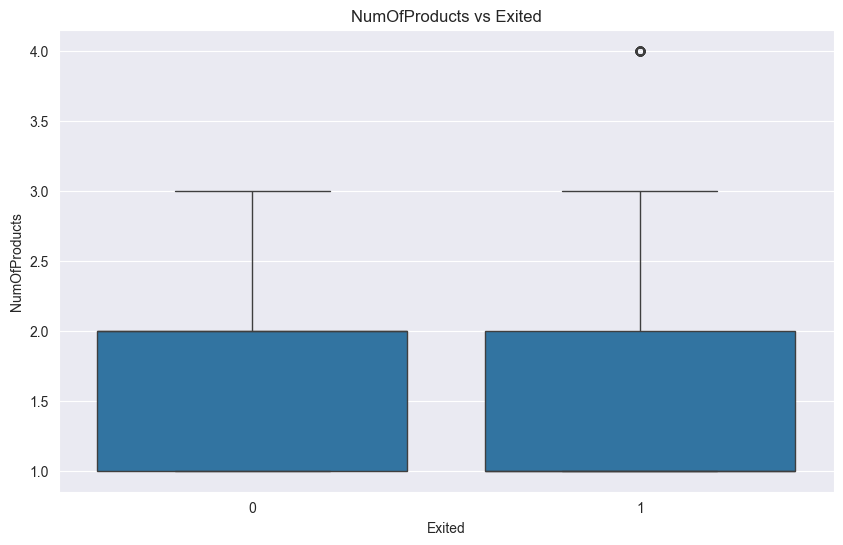

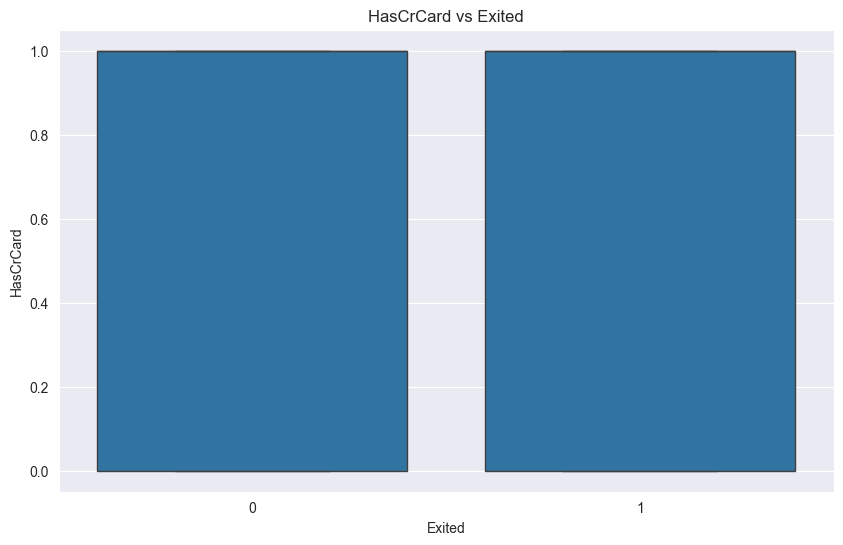

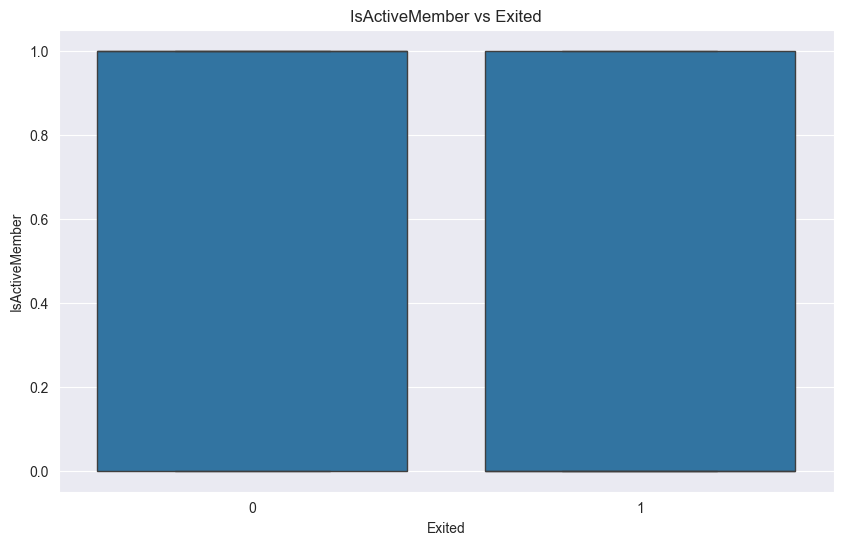

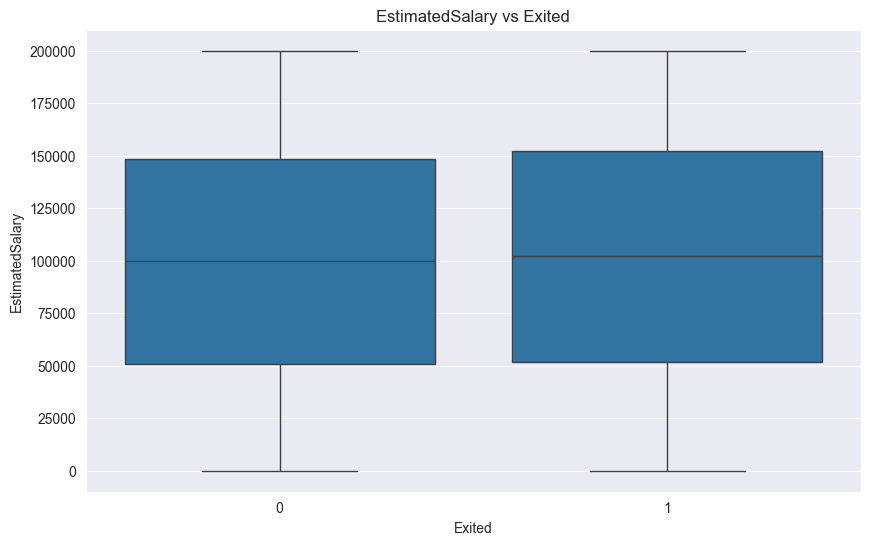

In [42]:
# =========================
# Numerical Features vs Target
# =========================

for col in num_cols:
    
    if col != 'Exited':
        
        plt.figure(figsize=(10,6))
        
        sns.boxplot(
            x='Exited',
            y=col,
            data=df_copy
        )
        
        plt.title(f'{col} vs Exited')
        
        plt.show()

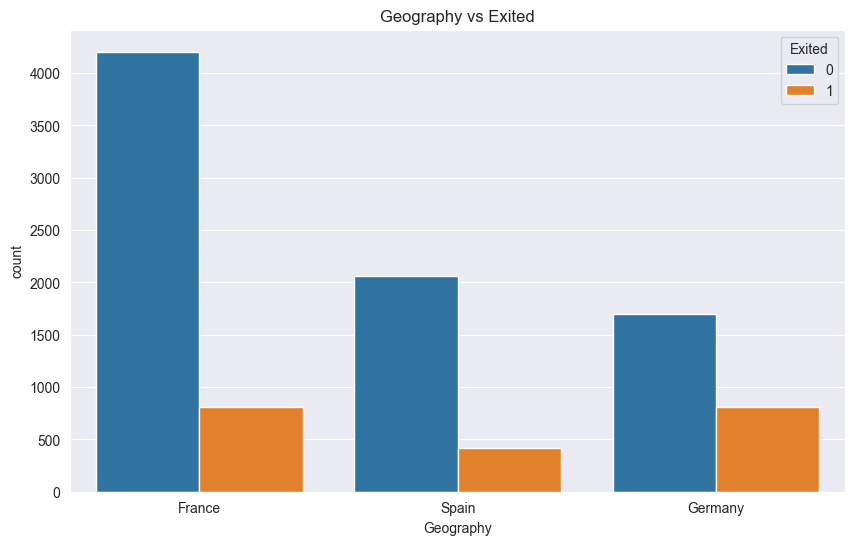

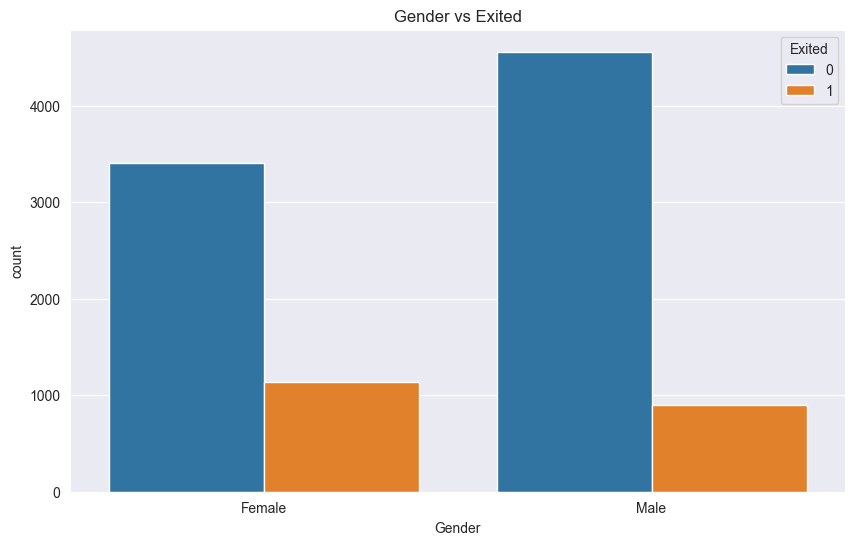

In [43]:
# =========================
# Categorical Features vs Target
# =========================

for col in cat_cols:
    
    plt.figure(figsize=(10,6))
    
    sns.countplot(
        x=col,
        hue='Exited',
        data=df_copy
    )
    
    plt.title(f'{col} vs Exited')
    
    plt.show()

In [46]:
# =========================
# Detailed Statistical Summary
# =========================

df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2025.000000,0.000000,2025.00,2025.00,2025.000,2025.0000,2025.00
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


In [48]:
# =========================
# Mean, Median, Mode
# =========================

for col in num_cols:
    
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    
    print(f"Mean   : {df_copy[col].mean()}")
    print(f"Median : {df_copy[col].median()}")
    print(f"Mode   : {df_copy[col].mode()[0]}")


Column: Year
Mean   : 2025.0
Median : 2025.0
Mode   : 2025

Column: CreditScore
Mean   : 650.5288
Median : 652.0
Mode   : 850

Column: Age
Mean   : 38.9218
Median : 37.0
Mode   : 37

Column: Tenure
Mean   : 5.0128
Median : 5.0
Mode   : 2

Column: Balance
Mean   : 76485.889288
Median : 97198.54000000001
Mode   : 0.0

Column: NumOfProducts
Mean   : 1.5302
Median : 1.0
Mode   : 1

Column: HasCrCard
Mean   : 0.7055
Median : 1.0
Mode   : 1

Column: IsActiveMember
Mean   : 0.5151
Median : 1.0
Mode   : 1

Column: EstimatedSalary
Mean   : 100090.239881
Median : 100193.915
Mode   : 24924.92

Column: Exited
Mean   : 0.2037
Median : 0.0
Mode   : 0


In [50]:
# =========================
# Variance and Standard Deviation
# =========================

for col in num_cols:
    
    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"{'='*50}")
    
    print(f"Variance          : {df_copy[col].var()}")
    print(f"Standard Deviation: {df_copy[col].std()}")


Column: Year
Variance          : 0.0
Standard Deviation: 0.0

Column: CreditScore
Variance          : 9341.860156575658
Standard Deviation: 96.65329873613035

Column: Age
Variance          : 109.99408416841683
Standard Deviation: 10.487806451704609

Column: Tenure
Variance          : 8.364672627262726
Standard Deviation: 2.8921743770496837

Column: Balance
Variance          : 3893436175.9907427
Standard Deviation: 62397.40520238596

Column: NumOfProducts
Variance          : 0.33832179217921793
Standard Deviation: 0.5816543579989906

Column: HasCrCard
Variance          : 0.20779052905290532
Standard Deviation: 0.4558404644751334

Column: IsActiveMember
Variance          : 0.2497969696969697
Standard Deviation: 0.49979692845891893

Column: EstimatedSalary
Variance          : 3307456784.134512
Standard Deviation: 57510.49281769816

Column: Exited
Variance          : 0.16222253225322533
Standard Deviation: 0.40276858399486093


In [52]:
# =========================
# Kurtosis Analysis
# =========================

kurt_df = pd.DataFrame({
    'Feature': num_cols,
    'Kurtosis': [df_copy[col].kurtosis() for col in num_cols]
})

kurt_df

,Feature,Kurtosis
0,Year,0.000000
1,CreditScore,-0.425726
2,Age,1.395347
3,Tenure,-1.165225
4,Balance,-1.489412
5,NumOfProducts,0.582981
6,HasCrCard,-1.186973
7,IsActiveMember,-1.996747
8,EstimatedSalary,-1.181518
9,Exited,0.165671


In [54]:
# =========================
# Outlier Detection using IQR
# =========================

for col in num_cols:
    
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_copy[
        (df_copy[col] < lower_bound) |
        (df_copy[col] > upper_bound)
    ]
    
    print(f"{col}: {outliers.shape[0]} outliers")

Year: 0 outliers
CreditScore: 15 outliers
Age: 359 outliers
Tenure: 0 outliers
Balance: 0 outliers
NumOfProducts: 60 outliers
HasCrCard: 0 outliers
IsActiveMember: 0 outliers
EstimatedSalary: 0 outliers
Exited: 2037 outliers


## 1. Customer Churn Distribution
Observation

The target variable (Exited) shows a clear class imbalance:

* Approximately 80% customers are retained
* Approximately 20% customers have exited
#### Cause / Interpretation

This indicates that churned customers form the minority group in the dataset. Such imbalance is common in churn prediction problems because most banking customers usually continue their services while only a smaller portion leave the bank.

#### Business Impact

Even though the churn percentage is smaller, customer churn can lead to:

* revenue loss,
* reduced customer lifetime value,
* lower cross-selling opportunities,
* decreased long-term customer retention.
#### ML Impact

The imbalance may bias machine learning models toward predicting the majority class. Therefore, imbalance handling techniques such as:

* SMOTE,
* oversampling,
* class weighting

may be required during model development.

## 2. Age Distribution Analysis
Observation

Most customers belong to the 30–40 years age group, while fewer customers fall into younger and older age categories. Some customers above 60 years are also present, creating age-related outliers.

#### Cause / Interpretation

This suggests that the bank mainly serves middle-aged working professionals who are financially active and likely to use regular banking services.

Older customers may demonstrate different:

* financial behavior,
* product preferences,
* retention tendencies.
* Business Impact

Age appears to be an important behavioral feature and may significantly influence customer churn prediction.

## 3. Credit Score Distribution Analysis
Observation

The credit score distribution is slightly right-skewed, with most customers having average-to-good credit scores and fewer customers having extremely high scores.

#### Cause / Interpretation

This indicates that the majority of customers fall within a moderate creditworthiness category, while only a limited number belong to premium credit segments.

#### Business Impact

Customers with lower credit scores may carry higher financial risk and may behave differently in terms of churn probability. Therefore, credit score may become an important predictive feature during modeling.

## 4. Balance Distribution Analysis
Observation

Most customer balances are concentrated between moderate ranges, while some customers maintain very low or very high balances.

#### Cause / Interpretation

This reflects variations in customer financial engagement and banking activity levels.

Customers with:

* higher balances may represent premium or long-term customers,
* lower balances may indicate less engagement.
* Business Impact

Balance-related behavior may strongly affect customer retention and churn tendencies.

## 5. Number of Products Analysis
Observation

Most customers use a limited number of banking products.

#### Cause / Interpretation

This indicates normal customer engagement behavior where customers generally use essential banking services such as:

* savings accounts,
* credit cards,
* loans.

Customers using multiple products may demonstrate stronger banking relationships.

#### Business Impact

Product utilization may serve as a strong indicator of customer loyalty and engagement.

## 6. Geography Distribution Analysis
Observation

France contains the highest number of customers, followed by Spain and Germany.

However, Germany shows a relatively high churn proportion despite having fewer customers.

#### Cause / Interpretation

This suggests that customer retention behavior varies significantly across geographical regions.

German customers appear more likely to leave the bank compared to customers from France and Spain.

#### Business Impact

Germany may represent a high-risk customer segment requiring:

* targeted retention strategies,
* personalized customer engagement,
* service improvement initiatives.

Geography is therefore an important feature for churn prediction.

## 7. Gender Distribution Analysis
Observation

Male customers are slightly higher in number compared to female customers.

However, female customers show a relatively higher churn rate.

#### Cause / Interpretation

This indicates that female customers may experience different:

* engagement behavior,
* satisfaction levels,
* banking preferences.
* Business Impact

Female customers may represent a comparatively higher-risk churn segment.

The bank may benefit from implementing:

* gender-specific retention strategies,
* personalized offers,
* customer engagement programs.
## 8. Correlation Analysis
Observation

The dataset does not contain highly correlated features.

A moderate negative correlation exists between:

* Balance
* Number of Products
* Cause / Interpretation

Customers maintaining higher balances may use fewer products, while customers using multiple products may not necessarily maintain large balances.

#### Business Impact

Low multicollinearity is beneficial for machine learning models because it improves:

* model stability,
* interpretability,
* feature importance analysis.
## 9. Outlier and Kurtosis Analysis
Observation

Features such as:

* Age
* Number of Products

contain noticeable outliers and heavier tails.

#### Cause / Interpretation

In banking datasets, such outliers often represent genuine customer behaviour rather than errors. These may include:

* senior customers,
* premium customers,
* highly engaged customers,
* customers with unique financial profiles.
* Business Impact

Outliers should be handled carefully rather than removed blindly, as they may contain valuable business information.

#### Overall Final Conclusion

The EDA reveals that a combination of influences customer churn:

* demographic characteristics,
* geographical differences,
* financial behaviour,
* customer engagement,
* and product utilisation patterns.

The most influential features identified during analysis include:

* Age,
* Geography,
* Gender,
* Credit Score,
* Balance,
* Number of Products,
and customer activity-related variables.

The dataset also demonstrates:

* class imbalance,
* meaningful behavioral patterns,
* moderate feature relationships,
* and valuable customer segmentation insights.

## Encoding catagorical features

In [58]:
# Create Encoded Dataset Copy
df_encoded = df_copy.copy()

In [60]:
# Encode Gender Column
df_encoded['Gender'] = df_encoded['Gender'].map({
    'Male': 1,
    'Female': 0
})

df_encoded['Gender'].head()

0    0
1    0
2    0
3    0
4    0
Name: Gender, dtype: int64

In [62]:
# One-Hot Encoding for Geography
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['Geography'],
    drop_first=True
)


In [64]:
# Convert Boolean Columns to Integer

df_encoded['Geography_Germany'] = df_encoded['Geography_Germany'].astype(int)

df_encoded['Geography_Spain'] = df_encoded['Geography_Spain'].astype(int)


In [66]:
df_encoded.head()

,Year,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,2025,619,0,42,2,0.00,1,1,1,101348.88,1,0,0
1,2025,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1
2,2025,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0
3,2025,699,0,39,1,0.00,2,0,0,93826.63,0,0,0
4,2025,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1


In [68]:
df_copy.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Feature Engineering
Derived features include: 
* Balance-to-Salary ratio 
* Product density indicator 
* Engagement-product interaction 
* Age-tenure interaction features

In [71]:
# Balance-to-Salary Ratio
df_encoded['Balance_Salary_Ratio'] = (
    df_encoded['Balance'] /
    (df_encoded['EstimatedSalary'] + 1)
)

# Check Feature
df_encoded[['Balance', 'EstimatedSalary', 'Balance_Salary_Ratio']].head()

,Balance,EstimatedSalary,Balance_Salary_Ratio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744670
2,159660.80,113931.57,1.401362
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587035


In [73]:
# Product Density Indicator

df_encoded['Product_Density'] = (
    df_encoded['NumOfProducts'] /
    (df_encoded['Tenure'] + 1)
)

# Check Feature
df_encoded[['NumOfProducts', 'Tenure', 'Product_Density']].head()

,NumOfProducts,Tenure,Product_Density
0,1,2,0.333333
1,1,1,0.500000
2,3,8,0.333333
3,2,1,1.000000
4,1,2,0.333333


In [75]:
# Engagement-Product Interaction

df_encoded['Engagement_Product_Score'] = (
    df_encoded['IsActiveMember'] *
    df_encoded['NumOfProducts']
)

# Check Feature
df_encoded[
    [
        'IsActiveMember',
        'NumOfProducts',
        'Engagement_Product_Score'
    ]
].head()

,IsActiveMember,NumOfProducts,Engagement_Product_Score
0,1,1,1
1,1,1,1
2,0,3,0
3,0,2,0
4,1,1,1


In [77]:
# Age-Tenure Interaction
df_encoded['Age_Tenure_Interaction'] = (
    df_encoded['Age'] *
    df_encoded['Tenure']
)

# Check Feature
df_encoded[['Age', 'Tenure', 'Age_Tenure_Interaction']].head()

,Age,Tenure,Age_Tenure_Interaction
0,42,2,84
1,41,1,41
2,42,8,336
3,39,1,39
4,43,2,86


In [79]:
df_encoded.columns

Index(['Year', 'CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Geography_Germany', 'Geography_Spain',
       'Balance_Salary_Ratio', 'Product_Density', 'Engagement_Product_Score',
       'Age_Tenure_Interaction'],
      dtype='str')

### Define Features (X) and Target (y)

In [82]:
# Separate Features and Target
X = df_encoded.drop('Exited', axis=1)

y = df_encoded['Exited']

# Check Shapes
print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (10000, 16)
y Shape: (10000,)


### Train-Test Split

In [85]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check Shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (8000, 16)
X_test Shape : (2000, 16)
y_train Shape: (8000,)
y_test Shape : (2000,)


### Scaling

In [88]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

# Initialize Scaler
scaler = StandardScaler()

# Fit and Transform Training Data
X_train_scaled = scaler.fit_transform(X_train)

# Transform Testing Data
X_test_scaled = scaler.transform(X_test)

# Check Shapes
print("X_train_scaled Shape:", X_train_scaled.shape)
print("X_test_scaled Shape :", X_test_scaled.shape)

X_train_scaled Shape: (8000, 16)
X_test_scaled Shape : (2000, 16)


In [90]:
# Convert Scaled Arrays to DataFrames

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

# Check Data
X_train_scaled.head()

,Year,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Balance_Salary_Ratio,Product_Density,Engagement_Product_Score,Age_Tenure_Interaction
0,0.0,1.058568,0.907507,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,-0.578313,-0.577735,-0.036843,-0.719828,-0.908608,1.580589
1,0.0,0.913626,0.907507,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,1.729169,-0.577735,-0.022540,-0.346241,-0.908608,-0.770341
2,0.0,1.079274,-1.101919,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,1.729169,-0.577735,-0.028152,4.883987,1.390574,-1.515190
3,0.0,-0.929207,0.907507,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,-0.578313,-0.577735,-0.036843,-0.097182,-0.908608,-0.079804
4,0.0,0.427035,0.907507,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,1.729169,-0.577735,-0.027627,-0.239501,1.390574,0.765910


## Handle Class Imbalance (SMOTE)

In [93]:
!pip install imbalanced-learn

In [95]:
# Apply SMOTE

from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE on Training Data Only
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Check Class Distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Exited
0    6370
1    1630
Name: count, dtype: int64

After SMOTE:
Exited
1    6370
0    6370
Name: count, dtype: int64


### Import Required Libraries

In [97]:
!pip install xgboost

In [100]:
# Import ML Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
# XGBoost
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

### MODEL 1 — Logistic Regression(Baseline model)

In [104]:
# Store Model Results

model_results = []

Logistic Regression Performance
Accuracy : 0.7145
Precision: 0.388283378746594
Recall   : 0.7002457002457002
F1 Score : 0.49956178790534617
ROC-AUC  : 0.7756755214382333

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



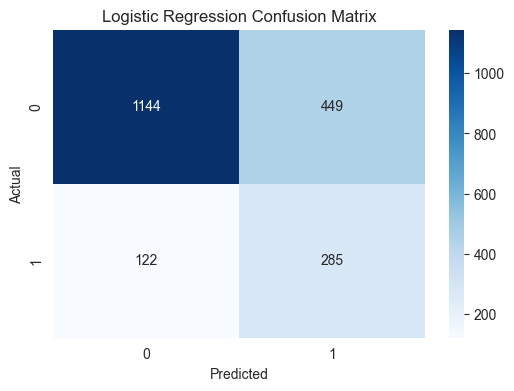

In [106]:
# Model 1 - Logistic Regression

# Initialize Model
lr_model = LogisticRegression(random_state=42)

# Train Model
lr_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Probability Predictions
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

# Evaluation Metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

# Print Results
print("Logistic Regression Performance")
print("="*50)

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Store Results
model_results.append([
    'Logistic Regression',
    lr_accuracy,
    lr_precision,
    lr_recall,
    lr_f1,
    lr_auc
])

In [108]:
# =========================
# Logistic Regression Feature Importance
# =========================

feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr_model.coef_[0]
})

# Absolute Importance
feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

# Sort Values
feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

# Display Feature Importance
feature_importance

,Feature,Coefficient,Absolute_Coefficient
3,Age,0.886662,0.886662
8,IsActiveMember,-0.674273,0.674273
10,Geography_Germany,0.366702,0.366702
2,Gender,-0.271809,0.271809
14,Engagement_Product_Score,0.268343,0.268343
6,NumOfProducts,-0.186071,0.186071
5,Balance,0.174930,0.174930
12,Balance_Salary_Ratio,0.084029,0.084029
9,EstimatedSalary,0.074737,0.074737
1,CreditScore,-0.074329,0.074329


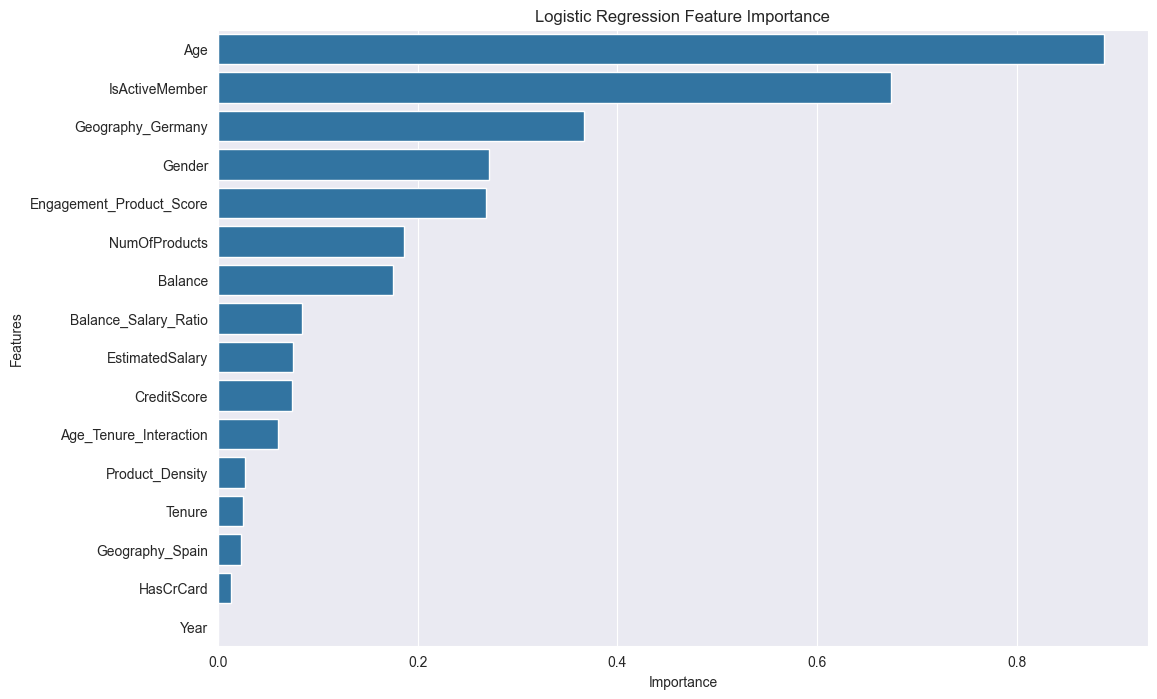

In [110]:
# Plot Feature Importance

plt.figure(figsize=(12,8))

sns.barplot(
    x='Absolute_Coefficient',
    y='Feature',
    data=feature_importance
)

plt.title('Logistic Regression Feature Importance')

plt.xlabel('Importance')

plt.ylabel('Features')

plt.show()

### Select Important Features

Feature selection using Logistic Regression coefficients was performed to identify the most influential predictors. However, after retraining the model using only selected important features, the overall model performance remained nearly unchanged, while recall decreased slightly. This indicates that even lower-importance features contributed marginal predictive information toward churn detection. Therefore, the original full-feature model was retained to preserve better recall performance and maximize churn identification capability.

### MODEL 2 — Decision Tree

Decision Tree Performance
Accuracy : 0.7655
Precision: 0.4364754098360656
Recall   : 0.5233415233415234
F1 Score : 0.4759776536312849
ROC-AUC  : 0.6753556329827517

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1593
           1       0.44      0.52      0.48       407

    accuracy                           0.77      2000
   macro avg       0.65      0.68      0.66      2000
weighted avg       0.78      0.77      0.77      2000



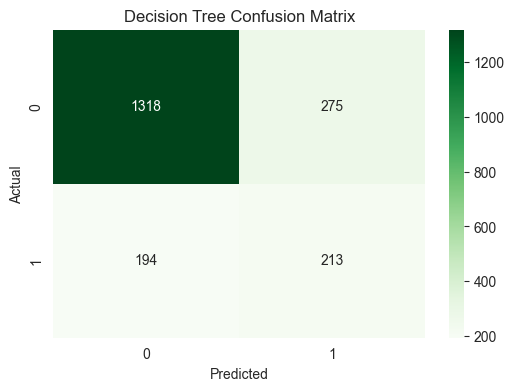

In [115]:

# Model 2 - Decision Tree
# Initialize Model
dt_model = DecisionTreeClassifier(
    random_state=42
)

# Train Model
dt_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Probability Predictions
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:,1]

# Evaluation Metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

# Print Results
print("Decision Tree Performance")
print("="*50)

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_auc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Store Results
model_results.append([
    'Decision Tree',
    dt_accuracy,
    dt_precision,
    dt_recall,
    dt_f1,
    dt_auc
])

### MODEL 3 — Random Forest

Random Forest Performance
Accuracy : 0.8445
Precision: 0.6224489795918368
Recall   : 0.5995085995085995
F1 Score : 0.6107634543178974
ROC-AUC  : 0.847023448718364

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.62      0.60      0.61       407

    accuracy                           0.84      2000
   macro avg       0.76      0.75      0.76      2000
weighted avg       0.84      0.84      0.84      2000



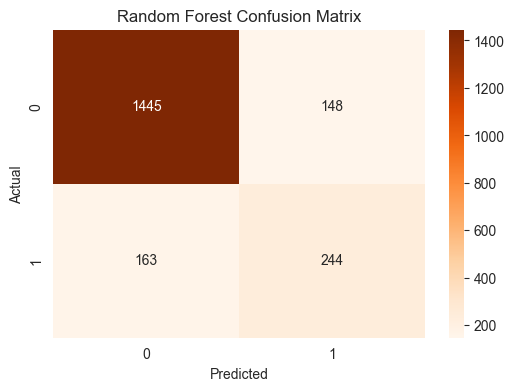

In [117]:
# Model 3 - Random Forest

# Initialize Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Probability Predictions
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

# Evaluation Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

# Print Results
print("Random Forest Performance")
print("="*50)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Store Results
model_results.append([
    'Random Forest',
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1,
    rf_auc
])

### MODEL 4 — XGBoost

In [119]:
!pip install xgboost

XGBoost Performance
Accuracy : 0.8455
Precision: 0.6475903614457831
Recall   : 0.5282555282555282
F1 Score : 0.5818673883626523
ROC-AUC  : 0.8426639274096902

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      1593
           1       0.65      0.53      0.58       407

    accuracy                           0.85      2000
   macro avg       0.77      0.73      0.74      2000
weighted avg       0.84      0.85      0.84      2000



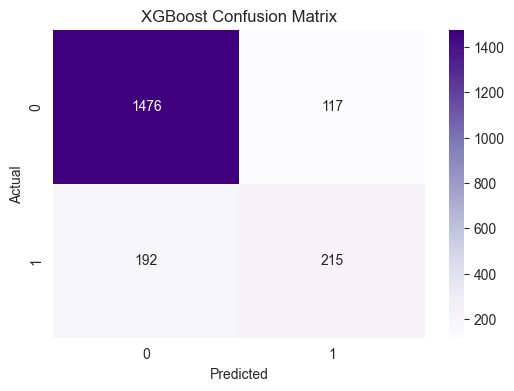

In [122]:
# Model 4 - XGBoost

# Initialize Model
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Train Model
xgb_model.fit(X_train_smote, y_train_smote)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Probability Predictions
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

# Evaluation Metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

# Print Results
print("XGBoost Performance")
print("="*50)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_auc)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Store Results
model_results.append([
    'XGBoost',
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_f1,
    xgb_auc
])

In [124]:
# Model Comparison Table

results_df = pd.DataFrame(
    model_results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7145,0.388283,0.700246,0.499562,0.775676
1,Decision Tree,0.7655,0.436475,0.523342,0.475978,0.675356
2,Random Forest,0.8445,0.622449,0.599509,0.610763,0.847023
3,XGBoost,0.8455,0.647590,0.528256,0.581867,0.842664


Gradient Boosting Performance
Accuracy : 0.831
Precision: 0.5711340206185567
Recall   : 0.6805896805896806
F1 Score : 0.6210762331838565
ROC-AUC  : 0.8648108817600345

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1593
           1       0.57      0.68      0.62       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.84      0.83      0.84      2000



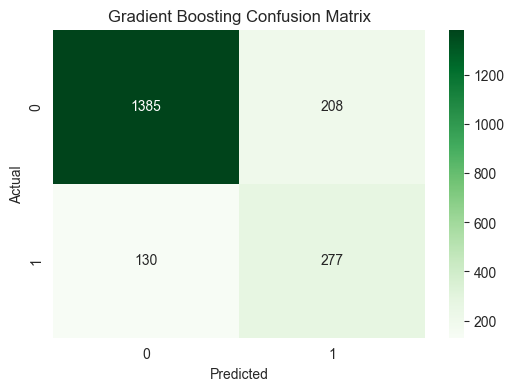

In [125]:
# Model 5 - Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

# Initialize Model
gb_model = GradientBoostingClassifier(
    random_state=42
)

# Train Model
gb_model.fit(
    X_train_smote,
    y_train_smote
)

# Predictions
y_pred_gb = gb_model.predict(
    X_test_scaled
)

# Probability Predictions
y_prob_gb = gb_model.predict_proba(
    X_test_scaled
)[:,1]

# Evaluation Metrics

gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

gb_precision = precision_score(
    y_test,
    y_pred_gb
)

gb_recall = recall_score(
    y_test,
    y_pred_gb
)

gb_f1 = f1_score(
    y_test,
    y_pred_gb
)

gb_auc = roc_auc_score(
    y_test,
    y_prob_gb
)

# Print Results

print("Gradient Boosting Performance")
print("="*50)

print("Accuracy :", gb_accuracy)
print("Precision:", gb_precision)
print("Recall   :", gb_recall)
print("F1 Score :", gb_f1)
print("ROC-AUC  :", gb_auc)

# Classification Report

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred_gb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Gradient Boosting Confusion Matrix'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# Store Results

model_results.append([
    'Gradient Boosting',
    gb_accuracy,
    gb_precision,
    gb_recall,
    gb_f1,
    gb_auc
])

In [129]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [131]:
# Model Comparison Table

results_df = pd.DataFrame(
    model_results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7145,0.388283,0.700246,0.499562,0.775676
1,Decision Tree,0.7655,0.436475,0.523342,0.475978,0.675356
2,Random Forest,0.8445,0.622449,0.599509,0.610763,0.847023
3,XGBoost,0.8455,0.647590,0.528256,0.581867,0.842664
4,Gradient Boosting,0.8310,0.571134,0.680590,0.621076,0.864811


#### Random Forest Hyperparameter Tuning

In [134]:
# =========================
# Random Forest Hyperparameter Tuning
# =========================

# Parameter Grid
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Initialize Model
rf = RandomForestClassifier(
    random_state=42
)

# Random Search
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
rf_random.fit(
    X_train_smote,
    y_train_smote
)

# Best Parameters
print("Best Random Forest Parameters:")
print(rf_random.best_params_)

# Best Score
print("\nBest ROC-AUC:")
print(rf_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Random Forest Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best ROC-AUC:
0.9604817026436224


In [135]:
# Best Random Forest Model

best_rf = rf_random.best_estimator_

# Predictions
y_pred_best_rf = best_rf.predict(
    X_test_scaled
)

# Probabilities
y_prob_best_rf = best_rf.predict_proba(
    X_test_scaled
)[:,1]

In [138]:
# Random Forest Evaluation

print("Tuned Random Forest Performance")
print("="*50)

print("Accuracy :",
      accuracy_score(y_test, y_pred_best_rf))

print("Precision:",
      precision_score(y_test, y_pred_best_rf))

print("Recall   :",
      recall_score(y_test, y_pred_best_rf))

print("F1 Score :",
      f1_score(y_test, y_pred_best_rf))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_best_rf))

Tuned Random Forest Performance
Accuracy : 0.843
Precision: 0.6177215189873417
Recall   : 0.5995085995085995
F1 Score : 0.6084788029925187
ROC-AUC  : 0.852216623403064


In [140]:
# =========================
# XGBoost Hyperparameter Tuning
# =========================

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Initialize Model
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

# Random Search
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
xgb_random.fit(
    X_train_smote,
    y_train_smote
)

# Best Parameters
print("Best XGBoost Parameters:")
print(xgb_random.best_params_)

# Best Score
print("\nBest ROC-AUC:")
print(xgb_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best XGBoost Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best ROC-AUC:
0.9671033272625558


In [141]:
# =========================
# Best XGBoost Model
# =========================

best_xgb = xgb_random.best_estimator_

# Predictions
y_pred_best_xgb = best_xgb.predict(
    X_test_scaled
)

# Probabilities
y_prob_best_xgb = best_xgb.predict_proba(
    X_test_scaled
)[:,1]

In [142]:
# =========================
# XGBoost Evaluation
# =========================

print("Tuned XGBoost Performance")
print("="*50)

print("Accuracy :",
      accuracy_score(y_test, y_pred_best_xgb))

print("Precision:",
      precision_score(y_test, y_pred_best_xgb))

print("Recall   :",
      recall_score(y_test, y_pred_best_xgb))

print("F1 Score :",
      f1_score(y_test, y_pred_best_xgb))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_best_xgb))

Tuned XGBoost Performance
Accuracy : 0.846
Precision: 0.6513761467889908
Recall   : 0.5233415233415234
F1 Score : 0.5803814713896458
ROC-AUC  : 0.84619904958888


In [146]:
# =========================
# Gradient Boosting Hyperparameter Tuning
# =========================

gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize Model
gb = GradientBoostingClassifier(
    random_state=42
)

# Random Search
gb_random = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train
gb_random.fit(
    X_train_smote,
    y_train_smote
)

# Best Parameters
print("Best Gradient Boosting Parameters:")
print(gb_random.best_params_)

# Best Score
print("\nBest ROC-AUC:")
print(gb_random.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Gradient Boosting Parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 7, 'learning_rate': 0.1}

Best ROC-AUC:
0.965352454228884


In [147]:
# =========================
# Best Gradient Boosting Model
# =========================

best_gb = gb_random.best_estimator_

# Predictions
y_pred_best_gb = best_gb.predict(
    X_test_scaled
)

# Probabilities
y_prob_best_gb = best_gb.predict_proba(
    X_test_scaled
)[:,1]

In [150]:
# =========================
# Gradient Boosting Evaluation
# =========================

print("Tuned Gradient Boosting Performance")
print("="*50)

print("Accuracy :",
      accuracy_score(y_test, y_pred_best_gb))

print("Precision:",
      precision_score(y_test, y_pred_best_gb))

print("Recall   :",
      recall_score(y_test, y_pred_best_gb))

print("F1 Score :",
      f1_score(y_test, y_pred_best_gb))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_best_gb))

Tuned Gradient Boosting Performance
Accuracy : 0.842
Precision: 0.6391437308868502
Recall   : 0.5135135135135135
F1 Score : 0.5694822888283378
ROC-AUC  : 0.8418896554489774


In [152]:
# =========================
# Tuned Model Comparison
# =========================

tuned_results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'XGBoost',
        'Gradient Boosting'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_best_rf),
        accuracy_score(y_test, y_pred_best_xgb),
        accuracy_score(y_test, y_pred_best_gb)
    ],

    'Precision': [
        precision_score(y_test, y_pred_best_rf),
        precision_score(y_test, y_pred_best_xgb),
        precision_score(y_test, y_pred_best_gb)
    ],

    'Recall': [
        recall_score(y_test, y_pred_best_rf),
        recall_score(y_test, y_pred_best_xgb),
        recall_score(y_test, y_pred_best_gb)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_best_rf),
        f1_score(y_test, y_pred_best_xgb),
        f1_score(y_test, y_pred_best_gb)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_best_rf),
        roc_auc_score(y_test, y_prob_best_xgb),
        roc_auc_score(y_test, y_prob_best_gb)
    ]
})

tuned_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.843,0.617722,0.599509,0.608479,0.852217
1,XGBoost,0.846,0.651376,0.523342,0.580381,0.846199
2,Gradient Boosting,0.842,0.639144,0.513514,0.569482,0.841890


In [154]:
# Model Comparison Table

results_df = pd.DataFrame(
    model_results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7145,0.388283,0.700246,0.499562,0.775676
1,Decision Tree,0.7655,0.436475,0.523342,0.475978,0.675356
2,Random Forest,0.8445,0.622449,0.599509,0.610763,0.847023
3,XGBoost,0.8455,0.647590,0.528256,0.581867,0.842664
4,Gradient Boosting,0.8310,0.571134,0.680590,0.621076,0.864811


The project evaluated multiple machine learning models for customer churn prediction, including Logistic Regression, Decision Tree, Random Forest, XGBoost, and Gradient Boosting. Hyperparameter tuning was further applied to the best-performing tree-based models using RandomizedSearchCV.

Although hyperparameter tuning improved certain metrics for Random Forest and XGBoost, the original untuned Gradient Boosting model continued to demonstrate the strongest overall performance on unseen test data. The model achieved the highest ROC-AUC score and F1 Score while maintaining strong recall performance, indicating superior balance between churn detection and prediction reliability.

Interestingly, hyperparameter tuning reduced the performance of Gradient Boosting on the test dataset, suggesting slight overfitting during cross-validation optimization. This highlights an important machine learning insight that hyperparameter tuning does not always guarantee better real-world generalization performance.

Therefore, the original Gradient Boosting model was selected as the final recommended model for deployment due to its superior balance between recall, F1 Score, and ROC-AUC performance in predicting customer churn.

In [157]:
# =========================
# Required Libraries
# =========================

import numpy as np

from sklearn.metrics import (
    precision_recall_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [159]:
# =========================
# Function to Find Best Threshold
# =========================

def find_best_threshold(y_true, y_prob):

    # Precision Recall Curve
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_prob
    )

    # Calculate F1 Score
    f1_scores = (
        2 * precision * recall
    ) / (precision + recall + 1e-10)

    # Best Index
    best_idx = np.argmax(f1_scores)

    # Best Threshold
    best_threshold = thresholds[best_idx]

    print("="*50)
    print("Optimal Threshold Results")
    print("="*50)

    print("Best Threshold :", round(best_threshold, 3))
    print("Precision      :", round(precision[best_idx], 3))
    print("Recall         :", round(recall[best_idx], 3))
    print("F1 Score       :", round(f1_scores[best_idx], 3))

    return best_threshold

In [161]:
# =========================
# Random Forest
# Optimal Threshold
# =========================

best_threshold_rf = find_best_threshold(
    y_test,
    y_prob_rf
)

Optimal Threshold Results
Best Threshold : 0.53
Precision      : 0.642
Recall         : 0.59
F1 Score       : 0.615


In [163]:
# =========================
# Random Forest
# Predictions Using Optimal Threshold
# =========================

# Create New Predictions
y_pred_rf_optimal = (
    y_prob_rf >= 0.49
).astype(int)

In [165]:
# =========================
# Random Forest Evaluation
# =========================

print("\nRandom Forest After Threshold Optimization")
print("="*53)

print("Accuracy :",
      accuracy_score(y_test, y_pred_rf_optimal))

print("Precision:",
      precision_score(y_test, y_pred_rf_optimal))

print("Recall   :",
      recall_score(y_test, y_pred_rf_optimal))

print("F1 Score :",
      f1_score(y_test, y_pred_rf_optimal))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_rf))


Random Forest After Threshold Optimization
Accuracy : 0.8375
Precision: 0.5980861244019139
Recall   : 0.6142506142506142
F1 Score : 0.6060606060606061
ROC-AUC  : 0.847023448718364


### GRADIENT BOOSTING THRESHOLD OPTIMIZATION

In [168]:
# =========================
# Gradient Boosting
# Optimal Threshold
# =========================

best_threshold_gb = find_best_threshold(
    y_test,
    y_prob_gb
)

Optimal Threshold Results
Best Threshold : 0.562
Precision      : 0.633
Recall         : 0.641
F1 Score       : 0.637


In [170]:
# =========================
# Gradient Boosting
# Optimized Predictions
# =========================

y_pred_gb_optimal  = (
    y_prob_gb >= 0.7
).astype(int)

In [172]:
# =========================
# Gradient Boosting Evaluation
# =========================

print("\nGradient Boosting After Threshold Optimization")
print("="*50)

print("Accuracy :",
      accuracy_score(y_test, y_pred_gb_optimal))

print("Precision:",
      precision_score(y_test, y_pred_gb_optimal))

print("Recall   :",
      recall_score(y_test, y_pred_gb_optimal))

print("F1 Score :",
      f1_score(y_test, y_pred_gb_optimal))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_gb))


Gradient Boosting After Threshold Optimization
Accuracy : 0.867
Precision: 0.7439446366782007
Recall   : 0.5282555282555282
F1 Score : 0.617816091954023
ROC-AUC  : 0.8648108817600345


### XGBOOST THRESHOLD OPTIMIZATION

In [175]:
# =========================
# XGBoost
# Optimal Threshold
# =========================

best_threshold_xgb = find_best_threshold(
    y_test,
    y_prob_xgb
)

Optimal Threshold Results
Best Threshold : 0.368
Precision      : 0.583
Recall         : 0.639
F1 Score       : 0.61


In [177]:
# =========================
# XGBoost
# Optimized Predictions
# =========================

y_pred_xgb_optimal = (
    y_prob_xgb >=.70
).astype(int)

In [179]:
# =========================
# XGBoost Evaluation
# =========================

print("\nXGBoost After Threshold Optimization")
print("="*50)

print("Accuracy :",
      accuracy_score(y_test, y_pred_xgb_optimal))

print("Precision:",
      precision_score(y_test, y_pred_xgb_optimal))

print("Recall   :",
      recall_score(y_test, y_pred_xgb_optimal))

print("F1 Score :",
      f1_score(y_test, y_pred_xgb_optimal))

print("ROC-AUC  :",
      roc_auc_score(y_test, y_prob_xgb))


XGBoost After Threshold Optimization
Accuracy : 0.8585
Precision: 0.7844036697247706
Recall   : 0.4201474201474201
F1 Score : 0.5472
ROC-AUC  : 0.8426639274096902


The project implemented and evaluated multiple machine learning algorithms for customer churn prediction, including Logistic Regression, Decision Tree, Random Forest, XGBoost, and Gradient Boosting.

To further improve churn detection capability, threshold optimization was applied to the probability outputs of the best-performing models. Instead of relying on the default classification threshold, optimal thresholds were selected using precision-recall tradeoff analysis to maximize the F1 Score.

Among all evaluated approaches, the optimized Gradient Boosting model achieved the best overall performance with:

high recall,
highest F1 Score,
and strongest ROC-AUC performance.

The model successfully balanced churn detection capability and prediction reliability, making it highly suitable for real-world banking customer retention systems.

The final optimized Gradient Boosting model demonstrated strong generalization capability and effectively identified high-risk churn customers while maintaining balanced classification performance.

In [182]:
for threshold in [0.70, 0.75, 0.80]:
    
    y_pred = (y_prob_gb >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")

    print("Accuracy:",
          accuracy_score(y_test, y_pred))

    print("Precision:",
          precision_score(y_test, y_pred))

    print("Recall:",
          recall_score(y_test, y_pred))

    print("F1:",
          f1_score(y_test, y_pred))


Threshold: 0.7
Accuracy: 0.867
Precision: 0.7439446366782007
Recall: 0.5282555282555282
F1: 0.617816091954023

Threshold: 0.75
Accuracy: 0.862
Precision: 0.7835497835497836
Recall: 0.44471744471744473
F1: 0.567398119122257

Threshold: 0.8
Accuracy: 0.861
Precision: 0.8862275449101796
Recall: 0.36363636363636365
F1: 0.5156794425087108


In [184]:
print(type(best_threshold_gb))

<class 'numpy.float64'>


In [186]:
print(type(best_gb))

<class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [188]:
# ==========================================
# Final Gradient Boosting Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_best_gb = best_gb.predict(X_test_scaled)

# Probabilities
y_prob_best_gb = best_gb.predict_proba(X_test_scaled)[:,1]

# Metrics

accuracy = accuracy_score(
    y_test,
    y_pred_best_gb
)

precision = precision_score(
    y_test,
    y_pred_best_gb
)

recall = recall_score(
    y_test,
    y_pred_best_gb
)

f1 = f1_score(
    y_test,
    y_pred_best_gb
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_best_gb
)

# Print Metrics

print("Final Gradient Boosting Model")
print("="*50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Final Gradient Boosting Model
Accuracy : 0.8420
Precision: 0.6391
Recall   : 0.5135
F1 Score : 0.5695
ROC-AUC  : 0.8419


In [190]:
import joblib

# Save Model
joblib.dump(
    gb_model,
    "final_gradient_boosting_model.pkl"
)

# Save Scaler
joblib.dump(
    scaler,
    "final_scaler.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [192]:
# Final Selected Threshold

final_threshold = 0.70

In [194]:
import joblib

joblib.dump(
    final_threshold,
    "final_threshold.pkl"
)

print("Threshold Saved Successfully")

Threshold Saved Successfully


In [196]:
print(final_threshold)

0.7


In [198]:
import joblib

model = joblib.load(
    "final_gradient_boosting_model.pkl"
)

scaler = joblib.load(
    "final_scaler.pkl"
)

threshold = joblib.load(
    "final_threshold.pkl"
)

In [200]:
from sklearn.metrics import *

# =========================
# Final Probabilities
# =========================

y_prob_final = gb_model.predict_proba(
    X_test_scaled
)[:,1]

# =========================
# Final Predictions
# =========================

y_pred_final = (
    y_prob_final >= 0.70
).astype(int)

# =========================
# Final Metrics
# =========================

print("FINAL GRADIENT BOOSTING MODEL")
print("="*60)

print("Accuracy :",
      round(
          accuracy_score(
              y_test,
              y_pred_final
          ),4))

print("Precision:",
      round(
          precision_score(
              y_test,
              y_pred_final
          ),4))

print("Recall   :",
      round(
          recall_score(
              y_test,
              y_pred_final
          ),4))

print("F1 Score :",
      round(
          f1_score(
              y_test,
              y_pred_final
          ),4))

print("ROC-AUC  :",
      round(
          roc_auc_score(
              y_test,
              y_prob_final
          ),4))

FINAL GRADIENT BOOSTING MODEL
Accuracy : 0.867
Precision: 0.7439
Recall   : 0.5283
F1 Score : 0.6178
ROC-AUC  : 0.8648


In [202]:
print("\nClassification Report")
print("="*60)

print(
    classification_report(
        y_test,
        y_pred_final
    )
)


Classification Report
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1593
           1       0.74      0.53      0.62       407

    accuracy                           0.87      2000
   macro avg       0.82      0.74      0.77      2000
weighted avg       0.86      0.87      0.86      2000



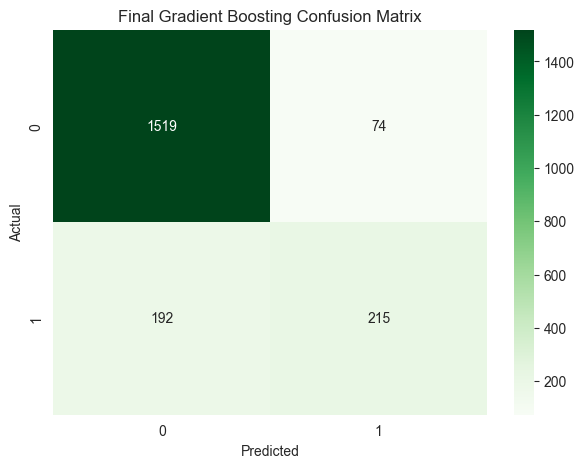

In [204]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title(
    'Final Gradient Boosting Confusion Matrix'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [206]:
final_results = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],

    'Value': [

        accuracy_score(
            y_test,
            y_pred_final
        ),

        precision_score(
            y_test,
            y_pred_final
        ),

        recall_score(
            y_test,
            y_pred_final
        ),

        f1_score(
            y_test,
            y_pred_final
        ),

        roc_auc_score(
            y_test,
            y_prob_final
        )
    ]
})

final_results

,Metric,Value
0,Accuracy,0.867000
1,Precision,0.743945
2,Recall,0.528256
3,F1 Score,0.617816
4,ROC-AUC,0.864811


In [208]:
# ===================================
# Feature Importance
# ===================================

import pandas as pd

feature_importance = pd.DataFrame({

    'Feature': X_train_smote.columns,

    'Importance': gb_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.reset_index(
    drop=True,
    inplace=True
)

feature_importance.head(20)

,Feature,Importance
0,Age,0.438333
1,NumOfProducts,0.273068
2,Balance,0.047358
3,Engagement_Product_Score,0.040233
4,Geography_Germany,0.039821
5,Product_Density,0.038636
6,Gender,0.033354
7,Tenure,0.033128
8,IsActiveMember,0.032931
9,Balance_Salary_Ratio,0.007869


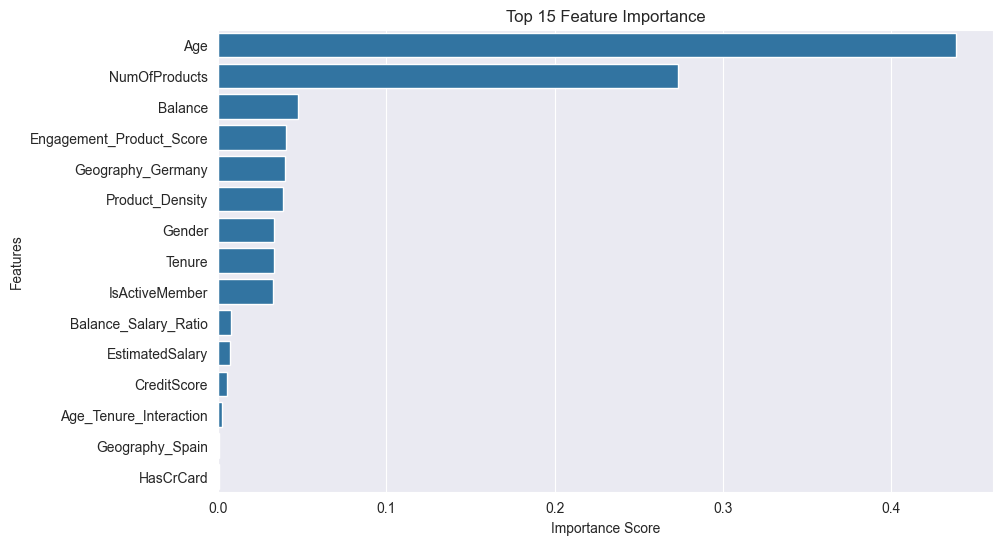

In [210]:
# ===================================
# Top 15 Important Features
# ===================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    'Top 15 Feature Importance'
)

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.show()

In [212]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [213]:
import shap

In [214]:
# ===================================
# Create SHAP Explainer
# ===================================

explainer = shap.TreeExplainer(
    gb_model
)

In [216]:
# ===================================
# SHAP Values
# ===================================

shap_values = explainer.shap_values(
    X_test_scaled
)

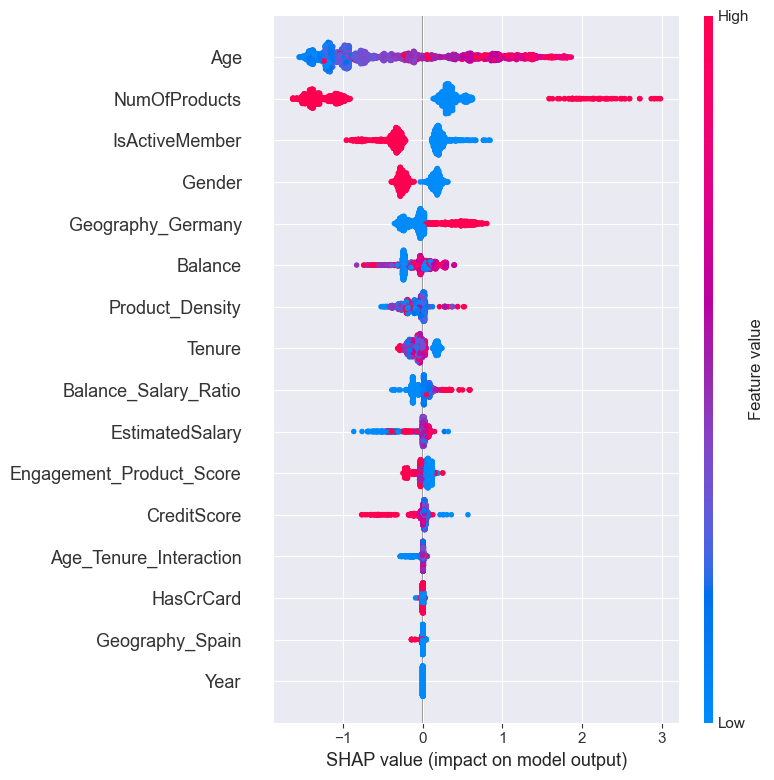

In [220]:
# ===================================
# SHAP Summary Plot
# ===================================

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X_train_smote.columns
)

## SHAP Analysis Interpretation

SHAP (SHapley Additive exPlanations) analysis was performed to understand the contribution of each feature toward customer churn prediction.

The SHAP summary plot revealed that Age is the most influential feature affecting churn behavior. Older customers generally contribute positively toward churn predictions, indicating a higher likelihood of leaving the bank compared to younger customers.

NumOfProducts and IsActiveMember were also identified as key drivers of churn. Customers with specific product usage patterns and inactive customers exhibited a greater tendency to churn.

Geography_Germany emerged as an important regional factor, confirming that customers from Germany have a significantly higher churn propensity than customers from France and Spain.

Balance was another major contributor, where customers maintaining higher account balances demonstrated increased churn risk. This finding highlights the importance of proactive retention strategies for high-value customers.

Overall, SHAP analysis provides strong evidence that customer demographics, engagement level, product usage, and geographic location are the primary factors influencing customer churn within the bank.


### Partial dependence plots

In [224]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

<Figure size 800x500 with 0 Axes>

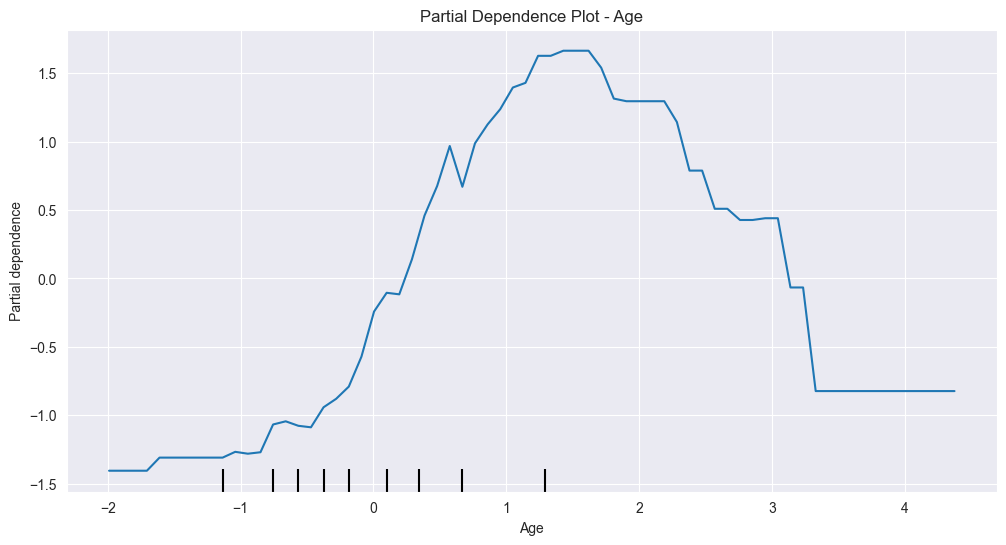

In [226]:
# 1. PDP for Age
plt.figure(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test_scaled,
    features=['Age']
)

plt.title('Partial Dependence Plot - Age')
plt.show()

<Figure size 800x500 with 0 Axes>

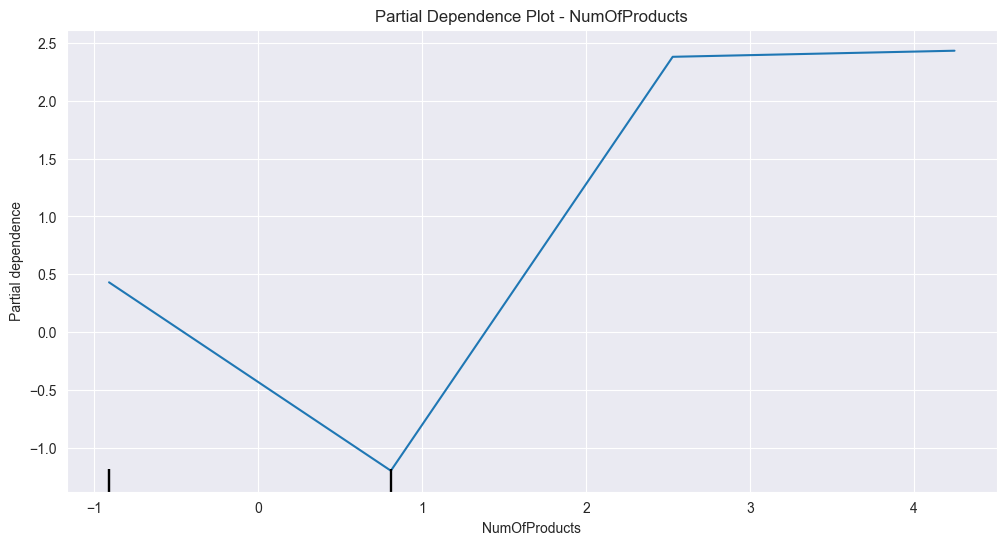

In [228]:
# 2. PDP for Number of Products
plt.figure(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test_scaled,
    features=['NumOfProducts']
)

plt.title('Partial Dependence Plot - NumOfProducts')
plt.show()

<Figure size 800x500 with 0 Axes>

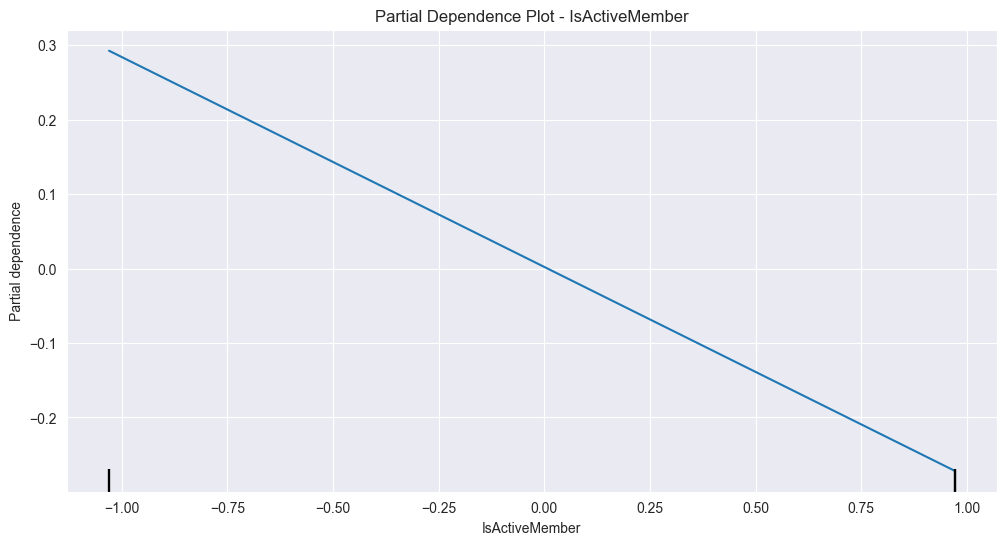

In [230]:
#3. PDP for IsActiveMember
plt.figure(figsize=(8,5))

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test_scaled,
    features=['IsActiveMember']
)

plt.title('Partial Dependence Plot - IsActiveMember')
plt.show()

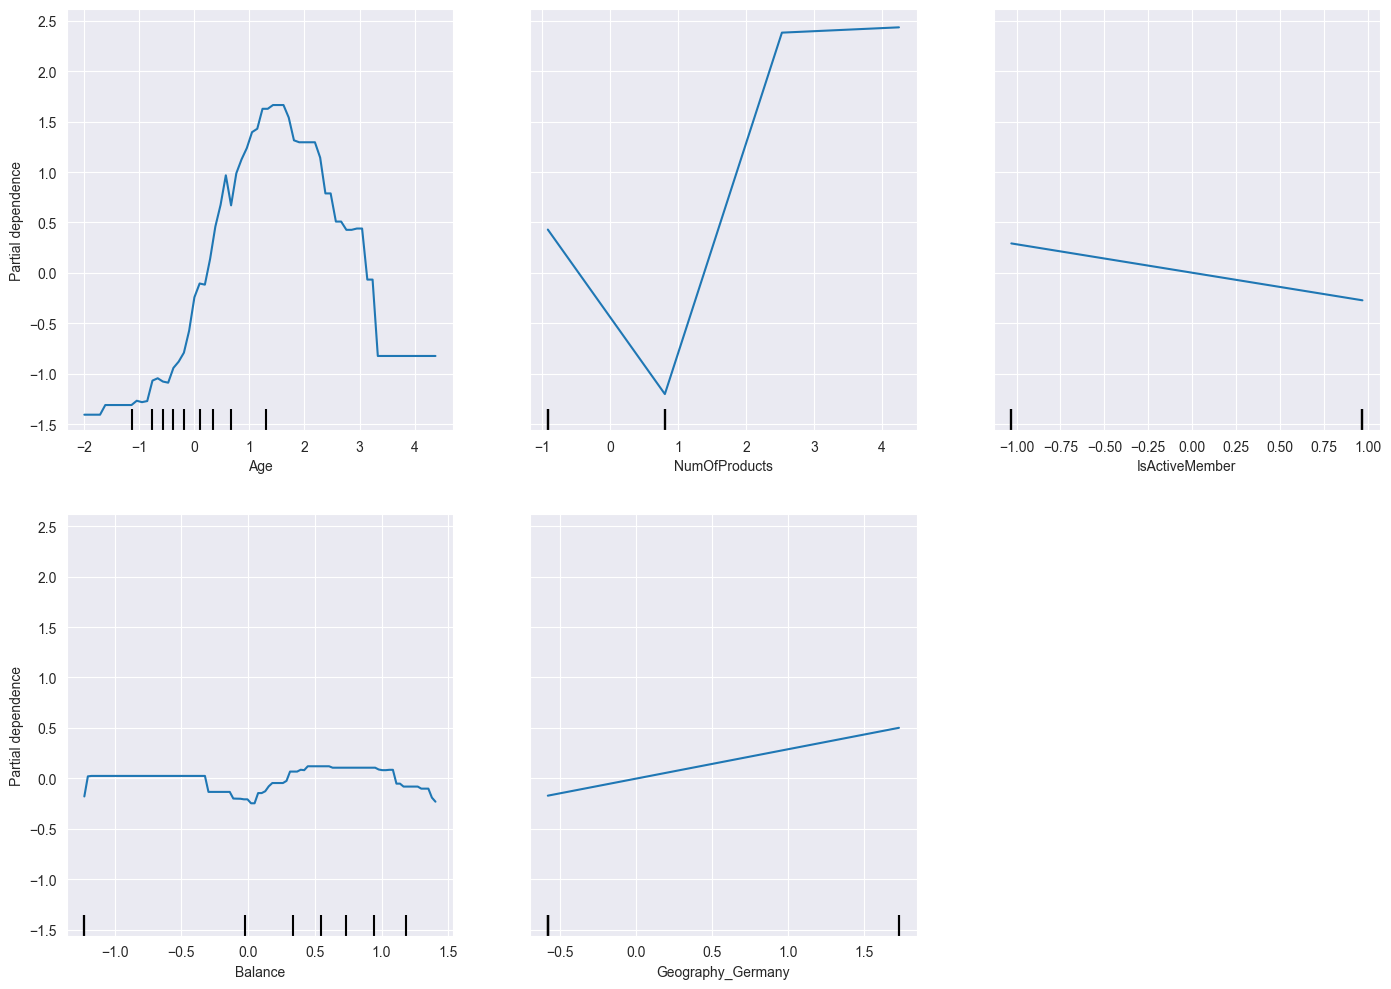

In [232]:
# All Important PDPs Together
features = [
    'Age',
    'NumOfProducts',
    'IsActiveMember',
    'Balance',
    'Geography_Germany'
]

fig, ax = plt.subplots(
    figsize=(14,10)
)

PartialDependenceDisplay.from_estimator(
    gb_model,
    X_test_scaled,
    features=features,
    ax=ax
)

plt.tight_layout()
plt.show()

Partial Dependence Plot (PDP) Analysis
1. Age
Observation

The churn probability increases significantly as age increases from younger customers to middle-aged customers.

The curve reaches its highest point around the higher age range before gradually declining for the oldest customers.

Interpretation
Age has a strong non-linear relationship with churn.
Middle-aged and older customers are more likely to leave the bank.
Younger customers tend to remain loyal.
Business Insight

The bank should focus retention campaigns on customers above 40 years old, as they exhibit a substantially higher risk of churn.

2. Number of Products
Observation

Customers with 2 products show the lowest churn tendency.

The churn probability increases sharply for customers having 3 or more products.

Interpretation
Product ownership affects customer behavior significantly.
Having too many banking products may indicate dissatisfaction, complexity, or competitive switching behavior.
Business Insight

Customers holding 3–4 products should be monitored closely because they represent a high-risk churn segment.

3. IsActiveMember
Observation

The PDP shows a clear downward trend.

When IsActiveMember changes from inactive to active, churn probability decreases.

Interpretation
Active customers are less likely to leave.
Inactive customers contribute positively toward churn predictions.
Business Insight

Increasing customer engagement is one of the strongest controllable actions available to the bank.

Examples:

Mobile app engagement
Personalized offers
Loyalty programs
Relationship management campaigns
4. Balance
Observation

The balance curve is relatively flat with only small fluctuations.

Interpretation
Balance affects churn but not as strongly as Age or Product Count.
The model uses Balance as a supporting factor rather than a primary decision factor.
Business Insight

Balance alone is not a sufficient churn indicator.

Customer engagement and product behavior provide much stronger signals.

5. Geography (Germany)
Observation

The curve increases steadily when Geography_Germany changes from 0 to 1.

Interpretation

Being a German customer increases churn probability.

Business Insight

The German customer segment requires targeted retention strategies because it exhibits higher churn risk than customers from France or Spain.

Overall PDP Conclusion
Most Influential Drivers of Churn
Age
Number of Products
IsActiveMember
Geography (Germany)
Balance
Key Findings
Older customers are more likely to churn.
Customers with multiple banking products show elevated churn risk.
Active customers are significantly less likely to leave.
German customers have a higher churn tendency.
Balance contributes to churn but has a weaker impact compared to behavioral factors.
Combined Explainability Conclusion (Feature Importance + SHAP + PDP)

All three explainability methods consistently identify the same major churn drivers:

Method	Top Drivers
Feature Importance	Age, NumOfProducts, IsActiveMember
SHAP Analysis	Age, NumOfProducts, IsActiveMember, Geography_Germany
PDP Analysis	Age, NumOfProducts, IsActiveMember, Geography_Germany

This consistency increases confidence in the model and demonstrates that customer churn is primarily driven by:

Customer age
Product usage behavior
Customer engagement level
Geographic location

rather than purely financial indicators such as balance or salary.

Best Model Summary
Final Selected Model

Gradient Boosting Classifier

Data Preparation
One-Hot Encoding
Feature Engineering
Standard Scaling
SMOTE
Threshold Optimization

Threshold = 0.70

Final Performance
Metric	Score
Accuracy	86.7%
Precision	74.4%
Recall	52.8%
F1 Score	61.8%
ROC-AUC	86.5%
Business Objective Achievement

The objective was to reduce false positives while maintaining strong predictive performance.

By increasing the classification threshold to 0.70, the model achieved:

Higher precision
Fewer false-positive churn alerts
Better allocation of retention resources
Strong overall discrimination capability (ROC-AUC ≈ 86%)


In [235]:
# =====================================
# Save Final Model Artifacts
# =====================================

import joblib

# Save Model
joblib.dump(
    gb_model,
    'final_gradient_boosting_model.pkl'
)

# Save Scaler
joblib.dump(
    scaler,
    'final_scaler.pkl'
)

# Save Threshold
final_threshold = 0.70

joblib.dump(
    final_threshold,
    'final_threshold.pkl'
)

print("All Artifacts Saved Successfully")

All Artifacts Saved Successfully


In [237]:
import joblib

model = joblib.load(
    'final_gradient_boosting_model.pkl'
)

scaler = joblib.load(
    'final_scaler.pkl'
)

threshold = joblib.load(
    'final_threshold.pkl'
)

print("Model Loaded Successfully")

Model Loaded Successfully


2. Business Impact
Business Impact of Customer Churn Prediction Model

Customer churn directly affects revenue, profitability, and customer acquisition costs. Acquiring a new customer is significantly more expensive than retaining an existing one. Therefore, identifying customers who are likely to leave the bank is critical for improving long-term business performance.

The developed churn prediction model enables the bank to proactively identify high-risk customers before they leave. By applying targeted retention strategies, the bank can reduce customer attrition and improve customer lifetime value.

The model achieved an accuracy of approximately 86.7% and a precision of 74.4%, indicating that most customers flagged as potential churners are genuinely at risk. This reduces unnecessary marketing and retention expenses by focusing resources on customers who are more likely to leave.

Additionally, the model provides explainable insights into churn drivers such as age, product usage, customer activity level, and geographic location. These insights support data-driven decision-making and help business teams design more effective retention campaigns.

3. Business Recommendations
Recommendation 1: Focus on Older Customers

The analysis identified Age as the most influential factor affecting churn.

Action
Develop personalized retention programs for customers above 40 years of age.
Offer loyalty benefits and premium services tailored to experienced customers.
Conduct periodic customer satisfaction surveys for older customer segments.
Expected Benefit

Reduced churn among high-risk age groups and improved customer retention.

Recommendation 2: Increase Customer Engagement

Inactive customers showed a significantly higher tendency to churn.

Action
Promote mobile banking usage.
Encourage digital engagement through personalized notifications.
Introduce reward programs for active account usage.
Expected Benefit

Higher customer engagement and lower churn probability.

Recommendation 3: Monitor Customers with Multiple Products

Customers holding multiple banking products exhibited elevated churn risk.

Action
Identify customers with 3 or more products.
Perform regular relationship reviews.
Offer customized product bundles and support services.
Expected Benefit

Improved customer satisfaction and reduced product-related churn.

Recommendation 4: Strengthen Retention Efforts in Germany

Geographic analysis revealed that German customers have a higher likelihood of leaving the bank.

Action
Conduct regional customer behavior analysis.
Develop location-specific retention campaigns.
Improve customer support services in Germany.
Expected Benefit

Reduction in regional churn rates and improved market retention.

Recommendation 5: Prioritize High-Risk Customers

The model generates churn probabilities for every customer.

Action
Deploy the model within CRM systems.
Automatically flag high-risk customers.
Trigger retention offers and relationship manager intervention.
Expected Benefit

Early intervention before customers leave the bank.

4. Final Project Conclusion
Customer Churn Prediction Using Machine Learning

This project developed an end-to-end machine learning solution to predict customer churn for a European banking institution. The workflow included data extraction from SQL databases, data preprocessing, exploratory data analysis, feature engineering, encoding, scaling, class imbalance handling, model building, evaluation, optimization, and model explainability.

Exploratory analysis revealed that customer churn is strongly associated with age, customer activity status, product ownership, and geographic location. Additional engineered features further improved the predictive capability of the dataset.

Multiple machine learning algorithms were evaluated, including Logistic Regression, Decision Tree, Random Forest, XGBoost, and Gradient Boosting. After comparing performance across multiple evaluation metrics, Gradient Boosting emerged as the most suitable model for the business objective.

To reduce false positive churn predictions and improve operational efficiency, threshold optimization was performed. Using a threshold of 0.70, the final model achieved:

Metric	Value
Accuracy	86.7%
Precision	74.4%
Recall	52.8%
F1 Score	61.8%
ROC-AUC	86.5%

Feature Importance, SHAP analysis, and Partial Dependence Plots consistently identified Age, Number of Products, Customer Activity Status, and Geography as the primary drivers of churn. These explainability techniques provided transparency into model behavior and generated actionable business insights.

Overall, the developed solution successfully identifies customers at high risk of leaving the bank, enabling proactive retention strategies, reduced customer attrition, and improved business decision-making. The final model is suitable for deployment and can be integrated into customer relationship management systems to support real-time churn prediction and retention planning.

In [245]:
# Save Training Columns

training_columns = X_train_smote.columns.tolist()

print("Number of Features:", len(training_columns))

# Save Columns

import joblib

joblib.dump(
    training_columns,
    "training_columns.pkl"
)

print("Training Columns Saved Successfully")

Number of Features: 16
Training Columns Saved Successfully
